## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

## Data Loading and Initial Inspection

## Load Dataset

In [4]:
df= pd.read_csv("/content/sample_data/Employee_Attrition - Raw_DataSet.csv")

## Display Raw Data

In [5]:
df

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,NaN,Male,Single,Finance,Manager,5.0,7332,81,NaN,...,No,9.0,48,16,4,1,1,49.0,3,No
1,2,48.0,Female,Divorced,Unknown,Assistant,4.0,6069,55,18.0,...,Yes,9.0,57,10,4,1,1,25.0,1,No
2,3,34.0,Female,Married,Marketing,Manager,4.0,11485,65,6.0,...,Yes,3.0,55,1,1,4,3,21.0,1,NaN
3,4,NaN,Female,Divorced,HR,Manager,4.0,18707,28,12.0,...,No,9.0,53,2,3,4,1,46.0,2,NaN
4,5,40.0,Male,Married,HR,Analyst,1.0,16398,92,3.0,...,No,1.0,54,11,1,1,1,43.0,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10045,798,27.0,Female,Divorced,HR,Executive,3.0,4612,84,22.0,...,Yes,1.0,59,10,1,1,4,21.0,2,No
10046,7726,20.0,Female,Single,Marketing,Assistant,3.0,13274,86,6.0,...,No,8.0,50,19,4,4,1,42.0,3,No
10047,761,33.0,Male,Divorced,Marketing,Analyst,5.0,3631,17,26.0,...,No,1.0,39,1,2,2,4,18.0,3,No
10048,3306,NaN,Female,Divorced,Finance,Analyst,5.0,15277,58,14.0,...,Yes,5.0,37,3,1,4,3,38.0,4,No


## Data Cleaning - General

## Check Data Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Employee_ID                    10050 non-null  int64  
 1   Age                            9224 non-null   float64
 2   Gender                         9251 non-null   object 
 3   Marital_Status                 9749 non-null   object 
 4   Department                     9422 non-null   object 
 5   Job_Role                       9153 non-null   object 
 6   Job_Level                      10048 non-null  float64
 7   Monthly_Income                 9181 non-null   object 
 8   Hourly_Rate                    10050 non-null  int64  
 9   Years_at_Company               9208 non-null   float64
 10  Years_in_Current_Role          10050 non-null  int64  
 11  Years_Since_Last_Promotion     10050 non-null  int64  
 12  Work_Life_Balance              9101 non-null  

## Check for Missing Values

In [7]:
df.isnull().sum()

,0
Employee_ID,0
Age,826
Gender,799
Marital_Status,301
Department,628
Job_Role,897
Job_Level,2
Monthly_Income,869
Hourly_Rate,0
Years_at_Company,842


## Drop Employee ID Column

In [8]:
df.drop('Employee_ID', axis=1, inplace=True)

## Check for Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(27)

## Remove Duplicate Rows

In [10]:
df.drop_duplicates(inplace=True)

## Verify Duplicate Removal

In [11]:
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

Number of duplicate rows after dropping: 0


## Data Cleaning - Column Specific

## Check Data Info After Duplicates Removal

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10023 entries, 0 to 10047
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            9201 non-null   float64
 1   Gender                         9227 non-null   object 
 2   Marital_Status                 9722 non-null   object 
 3   Department                     9400 non-null   object 
 4   Job_Role                       9128 non-null   object 
 5   Job_Level                      10021 non-null  float64
 6   Monthly_Income                 9156 non-null   object 
 7   Hourly_Rate                    10023 non-null  int64  
 8   Years_at_Company               9182 non-null   float64
 9   Years_in_Current_Role          10023 non-null  int64  
 10  Years_Since_Last_Promotion     10023 non-null  int64  
 11  Work_Life_Balance              9075 non-null   float64
 12  Job_Satisfaction               9479 non-null   floa

## Calculate Percentage of Missing Values

In [13]:
df.isna().mean().round(4) * 100

,0
Age,8.20
Gender,7.94
Marital_Status,3.00
Department,6.22
Job_Role,8.93
Job_Level,0.02
Monthly_Income,8.65
Hourly_Rate,0.00
Years_at_Company,8.39
Years_in_Current_Role,0.00


## Inspect 'Years at Company' Column

In [14]:
df["Years_at_Company"]

,Years_at_Company
0,NaN
1,18.000000
2,6.000000
3,12.000000
4,3.000000
...,...
10034,6.000000
10036,2.000000
10037,23.517635
10043,25.000000


## Inspect 'Years in Current Role' Column

In [15]:
df["Years_in_Current_Role"]

,Years_in_Current_Role
0,12
1,7
2,4
3,9
4,9
...,...
10034,12
10036,4
10037,10
10043,1


## Inspect 'Years Since Last Promotion' Column

In [16]:
df["Years_Since_Last_Promotion"]

,Years_Since_Last_Promotion
0,3
1,5
2,3
3,1
4,1
...,...
10034,6
10036,2
10037,6
10043,5


## Inspect 'Gender' Unique Values

In [17]:
df["Gender"].unique()

array(['Male', 'Female', nan, 'Woman', 'FEMALE', 'male', 'F', 'Man', 'M',
       'MALE', 'female'], dtype=object)

## Clean 'Gender' Column

In [18]:
df["Gender"]=df["Gender"].replace({
   'Female' : 'Female' ,
   'FEMALE' : 'Female' ,
   'Woman' : 'Female' ,
   'F' : 'Female' ,
   'female' : 'Female' ,

    'Male' : 'Male' ,
    'male': 'Male' ,
    'Man' : 'Male' ,
    'MALE' : 'Male' ,
    'M' : 'Male'  ,
    '...' : np.nan


})

## Inspect 'Marital Status' Unique Values

In [19]:
df["Marital_Status"].unique()

array(['Single', 'Divorced', 'Married', nan], dtype=object)

## Inspect 'Job Role' Unique Values

In [20]:
df["Job_Role"].unique()

array(['Manager', 'Assistant', 'Analyst', 'Executive', nan], dtype=object)

## Inspect 'Attrition' Unique Values

In [21]:
df['Attrition'].unique()

array(['No', nan, 'Yes', 'yes', '0', 'FALSE', 'no', 'NO', 'n', 'y', '1',
       'TRUE', 'N', 'YES', 'Y'], dtype=object)

## Clean 'Attrition' Column

In [22]:
df['Attrition'] = (
    df['Attrition']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': 1,
        'y': 1,
        'true': 1,
        '1': 1,

        'no': 0,
        'n': 0,
        'false': 0,
        '0': 0,

        'nan': np.nan
    })
)

/tmp/ipykernel_5521/1520410840.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


## Verify Cleaned 'Attrition' Values

In [23]:
df['Attrition'].unique()

array([ 0., nan,  1.])

## Check 'Overtime' Data Type

In [24]:
df["Overtime"].dtypes

dtype('O')

## Inspect 'Department' Unique Values

In [25]:
df["Department"].unique()

array(['Finance', 'Unknown', 'Marketing', 'HR', 'Sales', 'IT', nan,
       'FINANCE', 'I.T.', 'marketing', 'SALES', 'Information Technology',
       'Mktg', 'finance', 'Human Resources', 'it', 'Personnel', 'Tech',
       'MARKETING', 'sales', 'H.R.', 'Fin', 'Sale', 'hr'], dtype=object)

## Clean 'Department' Column

In [26]:
df['Department'] = (
    df['Department']
    .astype('object')
    .str.strip()
    .str.lower()
    .replace({

        'sales': 'Sales',
        'sale': 'Sales',

        'finance': 'Finance',
        'fin': 'Finance',

        'hr': 'HR',
        'human resources': 'HR',
        'h.r.': 'HR',
        'personnel': 'HR',

        'marketing': 'Marketing',

        'it': 'IT',
        'i.t.': 'IT',
        'tech': 'IT',
        'information technology': 'IT',
        'mktg': 'Marketing',

        'unknown': np.nan,
        '...': np.nan
    })
)

## Verify Cleaned 'Department' Values

In [27]:
df["Department"].unique()

array(['Finance', nan, 'Marketing', 'HR', 'Sales', 'IT'], dtype=object)

## Inspect 'Overtime' Unique Values

In [28]:
df["Overtime"].unique()

array(['No', 'Yes', nan, 'Y', 'yes', 'FALSE', '1', 'no', 'n', 'TRUE', 'N',
       '0', 'NO', 'YES', 'y'], dtype=object)

## Clean 'Overtime' Column

In [29]:
df['Overtime'] = (
    df['Overtime']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': 1,
        'y': 1,
        'true': 1,
        '1': 1,

        'no': 0,
        'n': 0,
        'false': 0,
        '0': 0,

        'nan': np.nan
    })
)

/tmp/ipykernel_5521/3013645463.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


## Verify Cleaned 'Overtime' Values

In [30]:
df['Overtime'].unique()

array([ 0.,  1., nan])

## Feature Engineering

## Calculate Overall Satisfaction

In [31]:
df['Overall_Satisfaction'] = (
    df['Job_Satisfaction'] +
    df['Work_Environment_Satisfaction'] +
    df['Relationship_with_Manager']
) / 3

## Calculate Promotion Wait Ratio

In [32]:
df['Promotion_Wait_Ratio'] = (
    df['Years_Since_Last_Promotion'] /
    (df['Years_at_Company'] + 1)
)

## Data Type Conversion

## Inspect Categorical Columns

In [33]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\n===== {col} ===telek")
    print(df[col].unique())


===== Gender ===telek
['Male' 'Female' nan]

===== Marital_Status ===telek
['Single' 'Divorced' 'Married' nan]

===== Department ===telek
['Finance' nan 'Marketing' 'HR' 'Sales' 'IT']

===== Job_Role ===telek
['Manager' 'Assistant' 'Analyst' 'Executive' nan]

===== Monthly_Income ===telek
['7332' '6069' '11485' ... '12592' '9287' '7225']


## Inspect Numerical Columns Ranges

In [34]:
for col in df.select_dtypes(include=['number']).columns:
    print(f"\n===== {col} ===telek")
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("Unique suspicious values:")
    print(df[col].isin([-1, 999, 9999]).sum())


===== Age ===telek
Min: -56.0
Max: 59.8252212
Unique suspicious values:
0

===== Job_Level ===telek
Min: 1.0
Max: 5.0
Unique suspicious values:
0

===== Hourly_Rate ===telek
Min: 15
Max: 99
Unique suspicious values:
0

===== Years_at_Company ===telek
Min: 1.0
Max: 29.87639332
Unique suspicious values:
0

===== Years_in_Current_Role ===telek
Min: 1
Max: 14
Unique suspicious values:
0

===== Years_Since_Last_Promotion ===telek
Min: 0
Max: 9
Unique suspicious values:
0

===== Work_Life_Balance ===telek
Min: 1.0
Max: 4.0
Unique suspicious values:
0

===== Job_Satisfaction ===telek
Min: 1.0
Max: 5.0
Unique suspicious values:
0

===== Performance_Rating ===telek
Min: 1
Max: 4
Unique suspicious values:
0

===== Training_Hours_Last_Year ===telek
Min: 0
Max: 99
Unique suspicious values:
0

===== Overtime ===telek
Min: 0.0
Max: 1.0
Unique suspicious values:
0

===== Project_Count ===telek
Min: 1.0
Max: 9.898370757
Unique suspicious values:
0

===== Average_Hours_Worked_Per_Week ===telek
Min: 30

## Inspect 'Gender' Unique Values After Cleaning

In [35]:
df["Gender"].unique()

array(['Male', 'Female', nan], dtype=object)

## Convert Numeric Columns to Numeric Type

In [36]:
numeric_cols = [
    'Age',
    'Job_Level',
    'Monthly_Income',
    'Hourly_Rate',
    'Years_at_Company',
    'Years_in_Current_Role',
    'Years_Since_Last_Promotion',
    'Work_Life_Balance',
    'Job_Satisfaction',
    'Performance_Rating',
    'Training_Hours_Last_Year',
    'Project_Count',
    'Distance_From_Home',
    'Absenteeism',
    'Average_Hours_Worked_Per_Week',
    'Work_Environment_Satisfaction',
    'Relationship_with_Manager',
    'Job_Involvement',
    'Income_Per_Level'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")

## Round Calculated Features

In [37]:

df['Overall_Satisfaction'] = df['Overall_Satisfaction'].round(2)

## Convert 'Marital Status' to Category

In [38]:
df["Marital_Status"]=df["Marital_Status"].astype('category')

## Convert 'Gender' to Category

In [39]:
df["Gender"]=df["Gender"].astype('category')

## Convert 'Department' to Category

In [40]:
df["Department"]=df["Department"].astype('category')

## Convert 'Job Role' to Category

In [41]:
df["Job_Role"]=df["Job_Role"].astype('category')

## Outlier Handling

## Filter 'Age' Outliers

In [42]:
df= df[(df["Age"] >= 0) & (df["Age"]<=100)]

## Check Data Info After Age Filtering

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9182 entries, 1 to 10047
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            9182 non-null   float64 
 1   Gender                         8449 non-null   category
 2   Marital_Status                 8907 non-null   category
 3   Department                     8333 non-null   category
 4   Job_Role                       8351 non-null   category
 5   Job_Level                      9180 non-null   float64 
 6   Monthly_Income                 7120 non-null   float64 
 7   Hourly_Rate                    9182 non-null   int64   
 8   Years_at_Company               8406 non-null   float64 
 9   Years_in_Current_Role          9182 non-null   int64   
 10  Years_Since_Last_Promotion     9182 non-null   int64   
 11  Work_Life_Balance              8312 non-null   float64 
 12  Job_Satisfaction               8692 no

## Exploratory Data Analysis (EDA)

## Visualize Numerical Distributions

/tmp/ipykernel_5521/1006217207.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


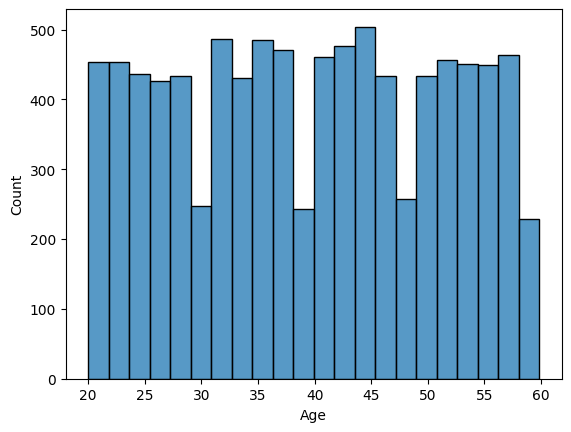

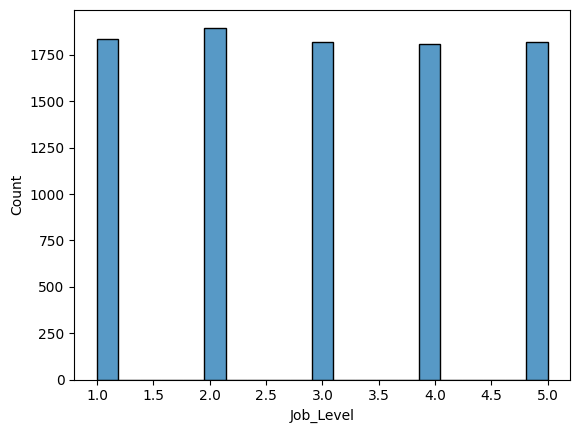

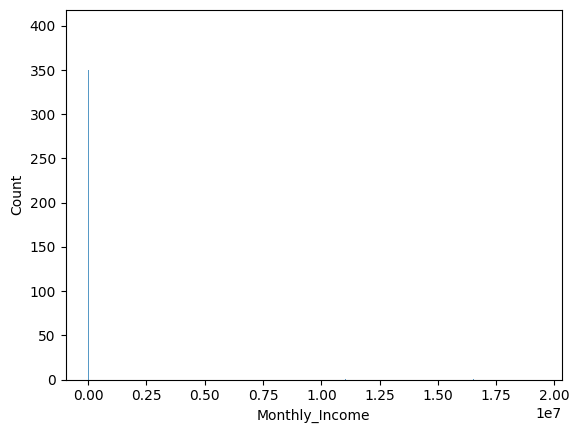

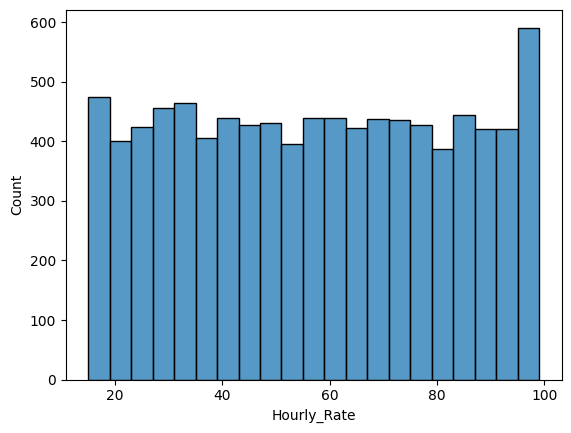

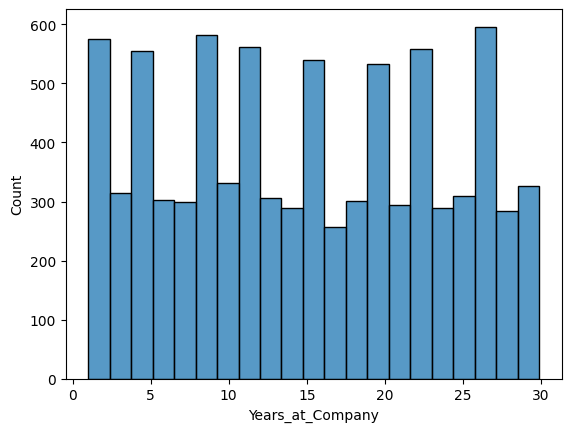

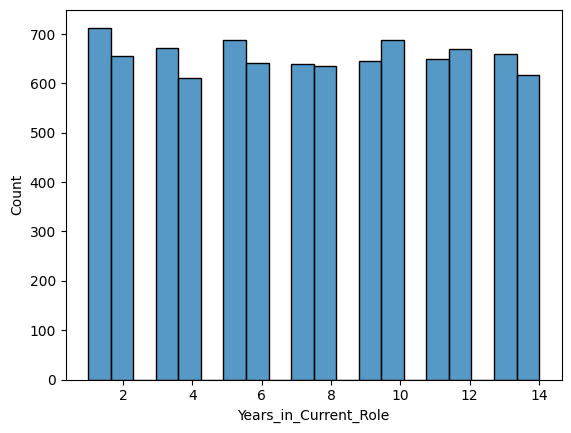

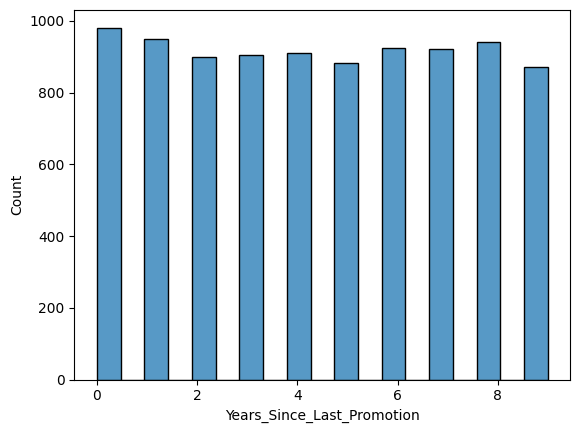

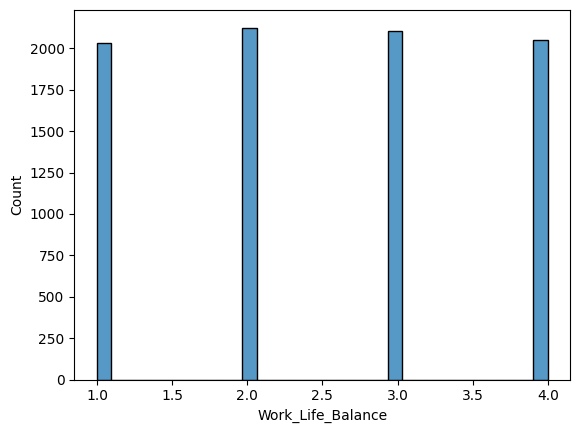

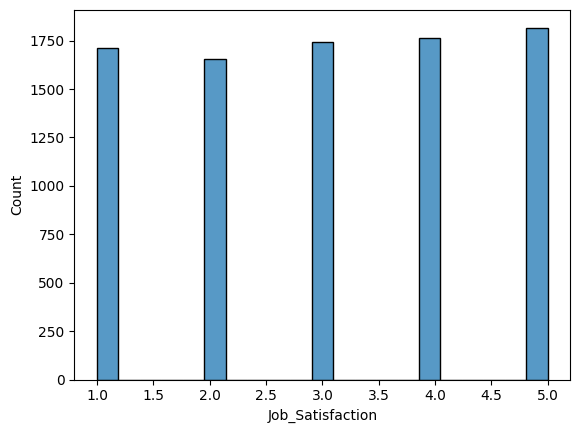

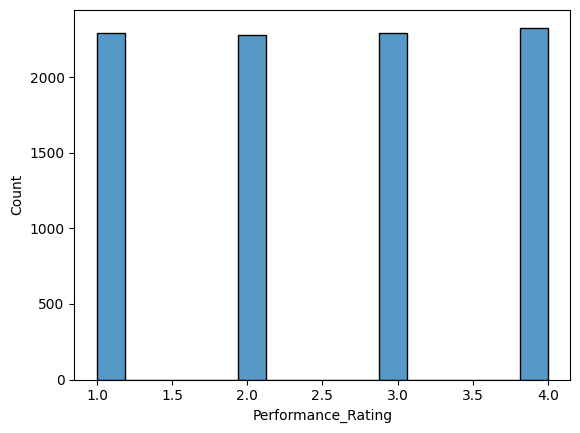

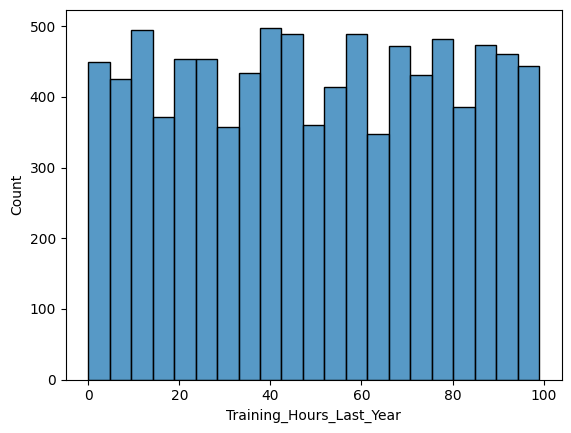

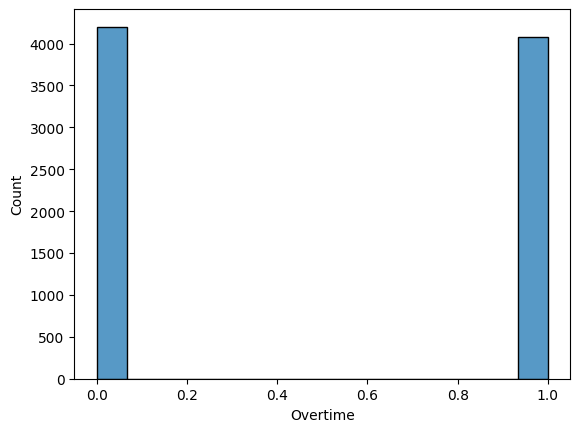

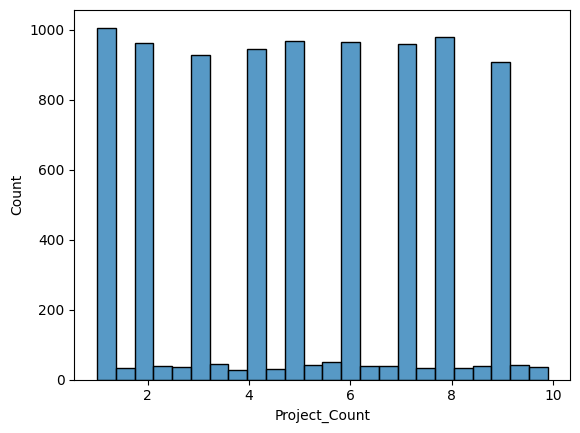

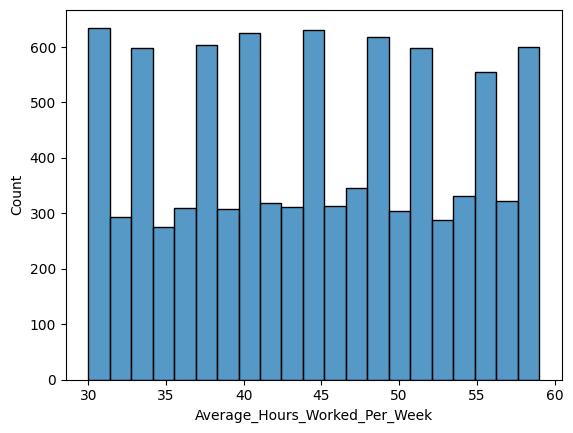

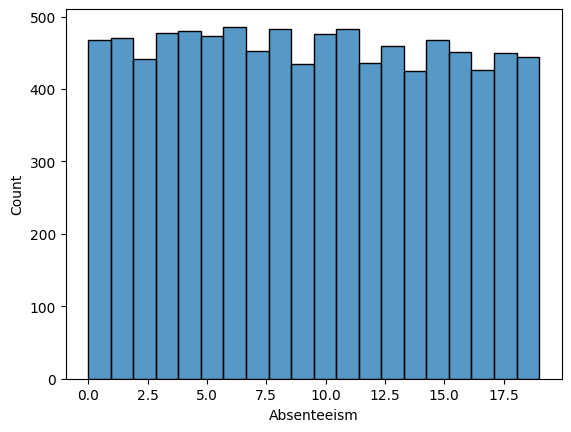

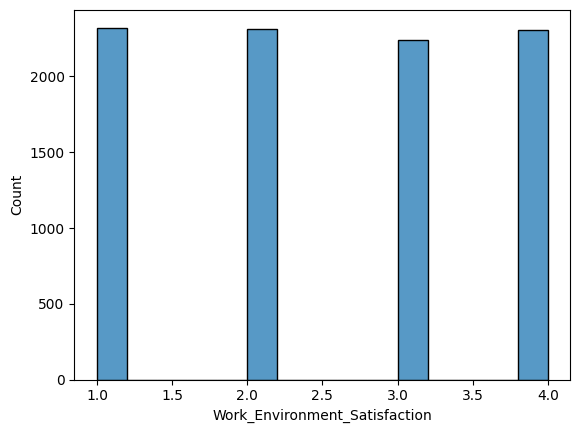

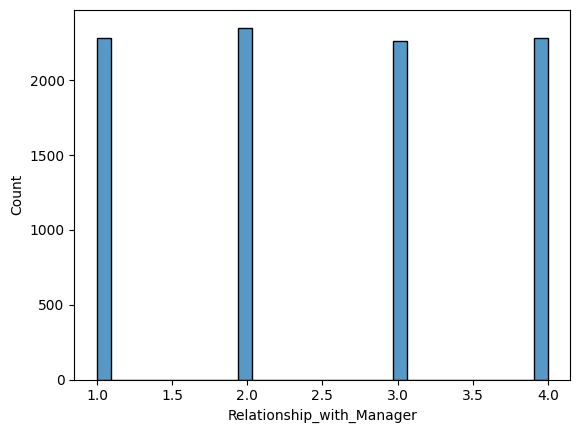

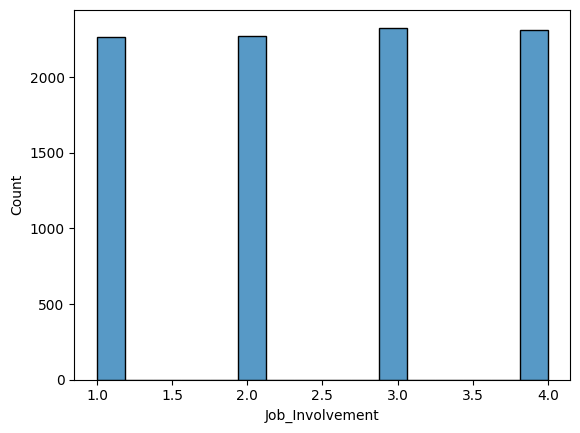

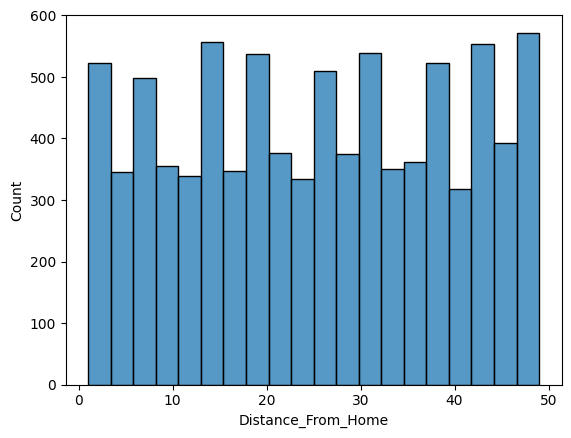

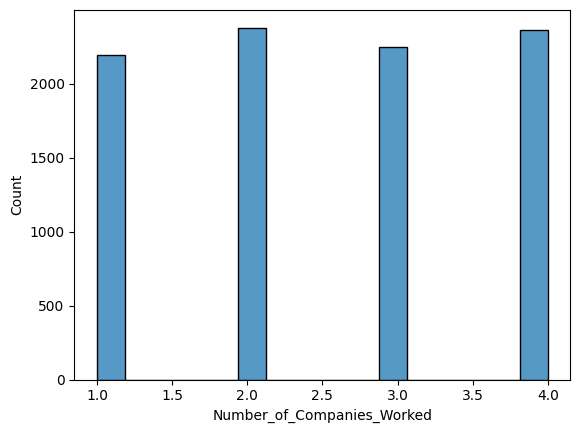

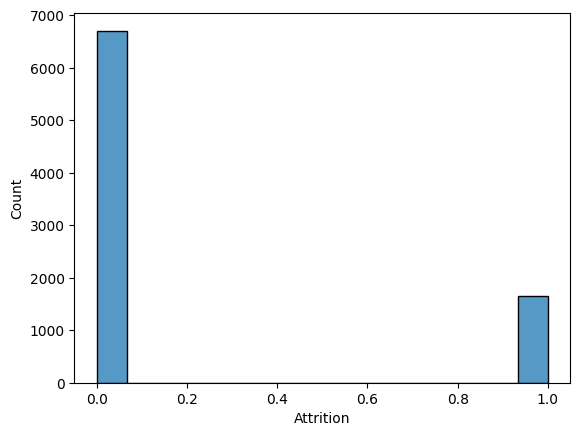

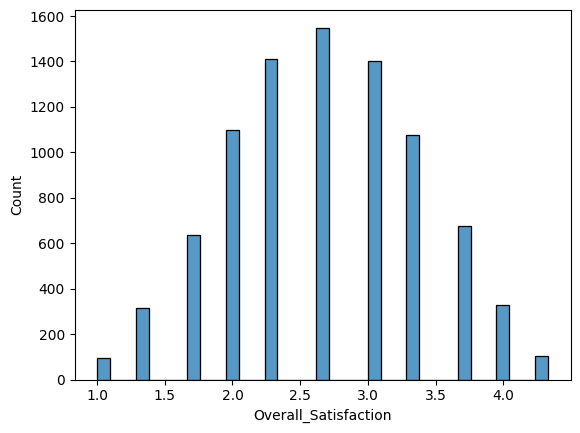

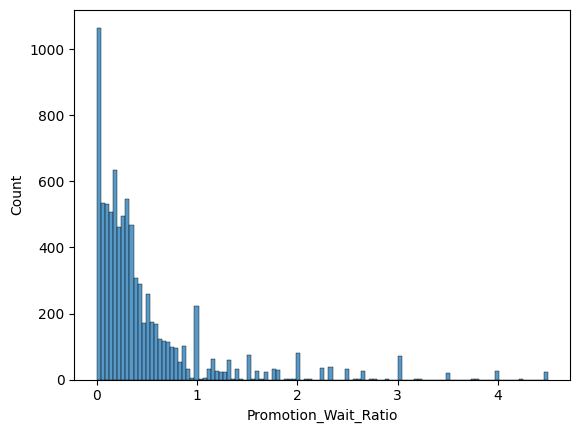

In [44]:
for col in df.select_dtypes('number').columns:
  plt.figure()
  sns.histplot(df[col])

## Describe 'Monthly Income'

In [45]:
df["Monthly_Income"].describe()

,Monthly_Income
count,7.120000e+03
mean,4.626857e+04
std,6.920937e+05
min,3.000000e+03
25%,7.178750e+03
50%,1.134950e+04
75%,1.569275e+04
max,1.934000e+07


## Describe 'Monthly Income' After Transformation

In [46]:
df["Monthly_Income"].describe()

,Monthly_Income
count,7.120000e+03
mean,4.626857e+04
std,6.920937e+05
min,3.000000e+03
25%,7.178750e+03
50%,1.134950e+04
75%,1.569275e+04
max,1.934000e+07


## Visualize Numerical Distributions After Transformation

/tmp/ipykernel_5521/1006217207.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


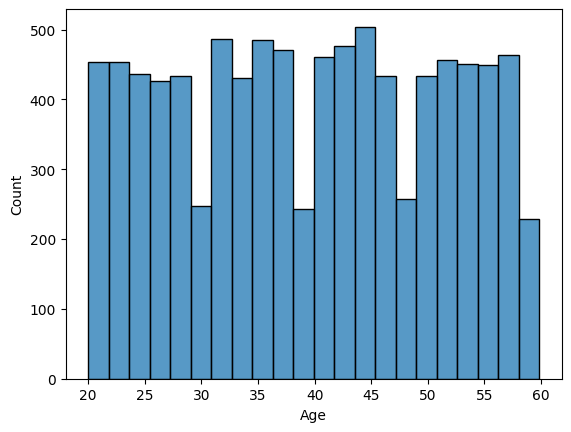

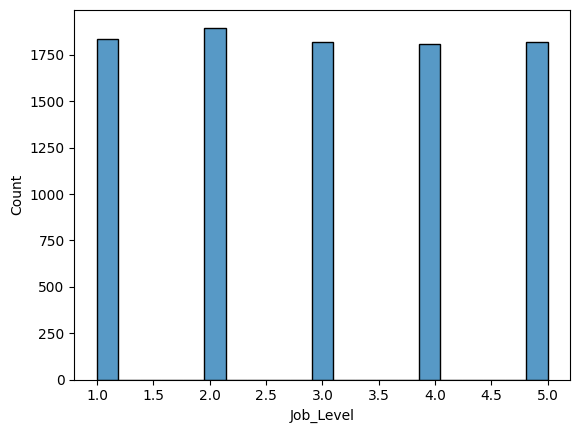

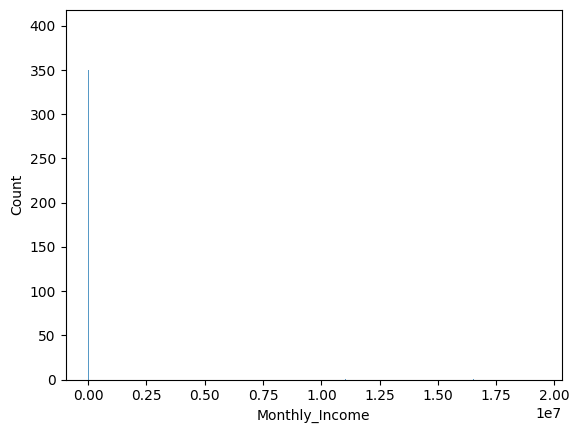

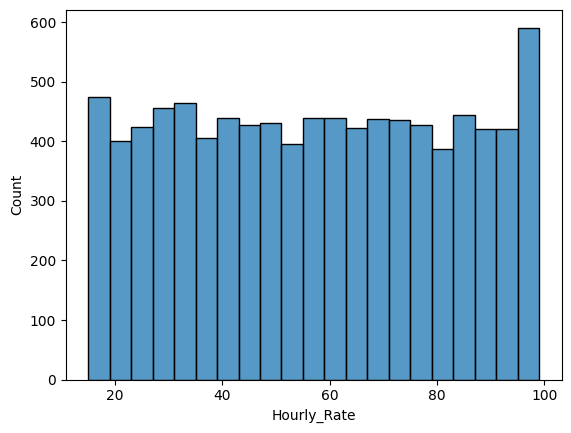

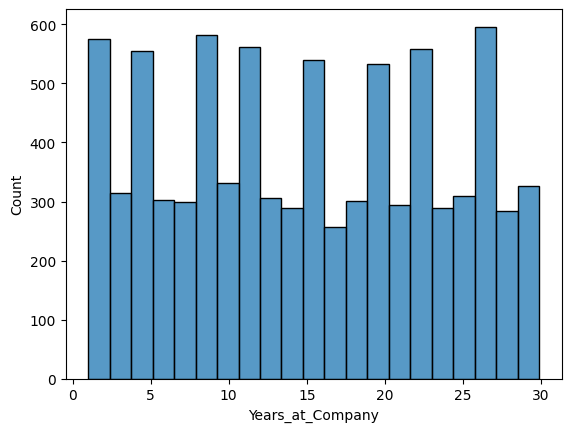

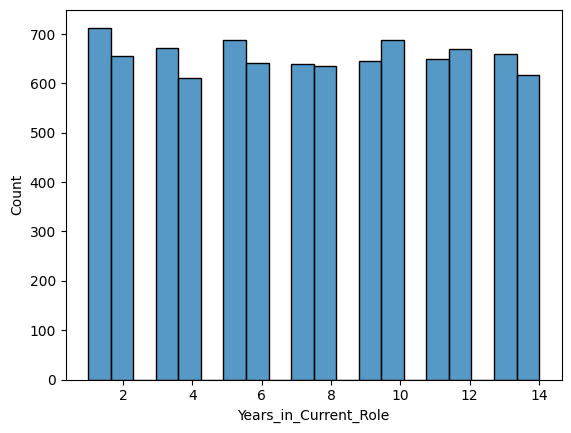

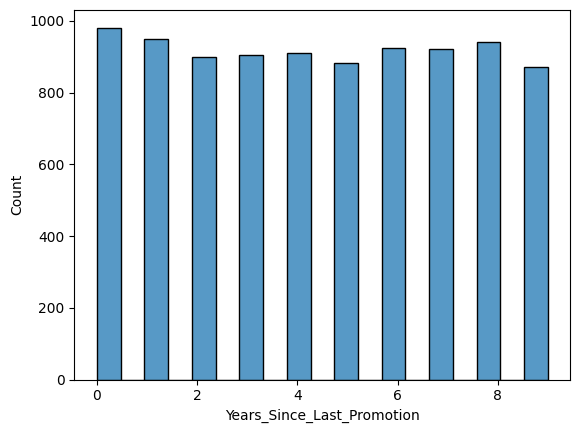

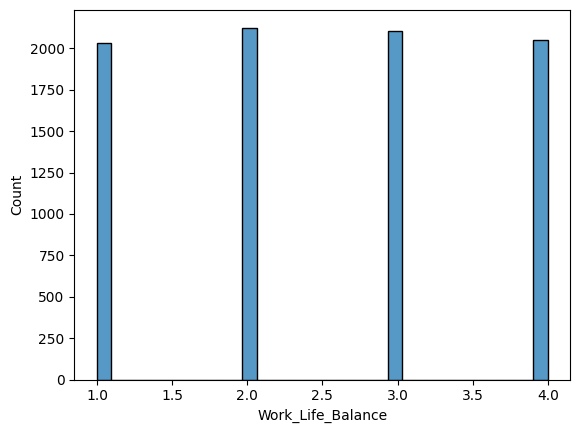

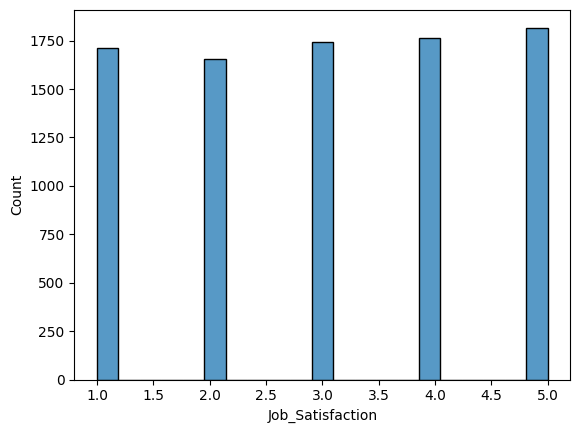

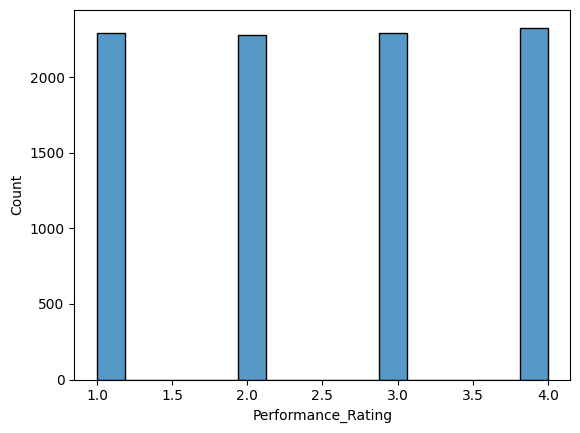

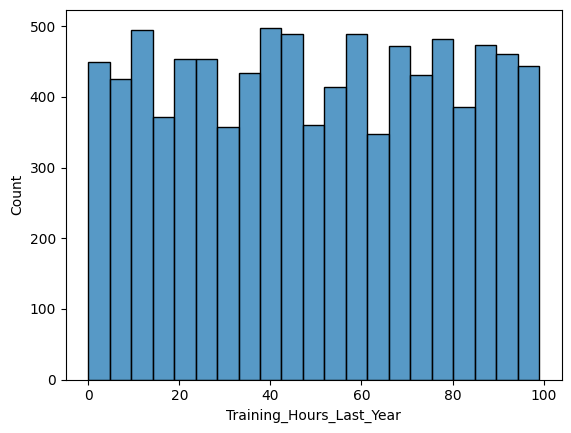

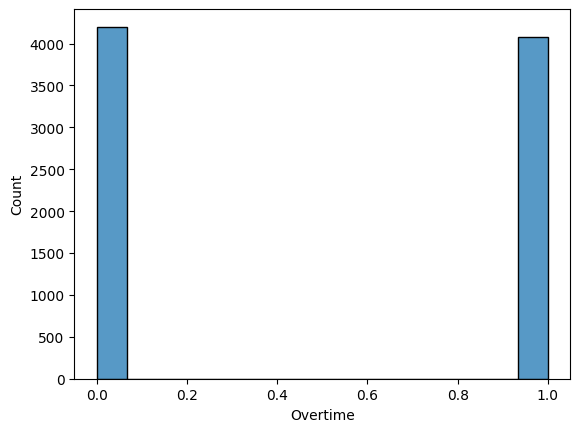

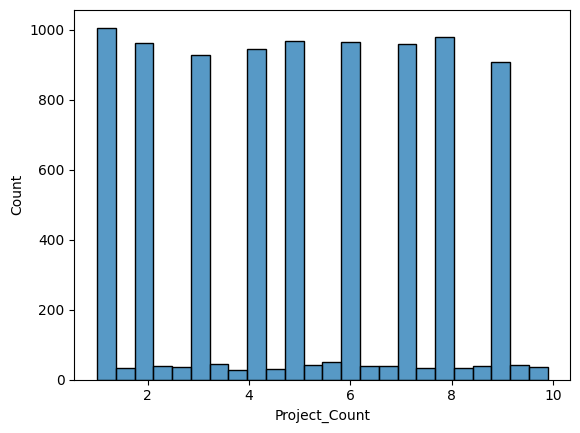

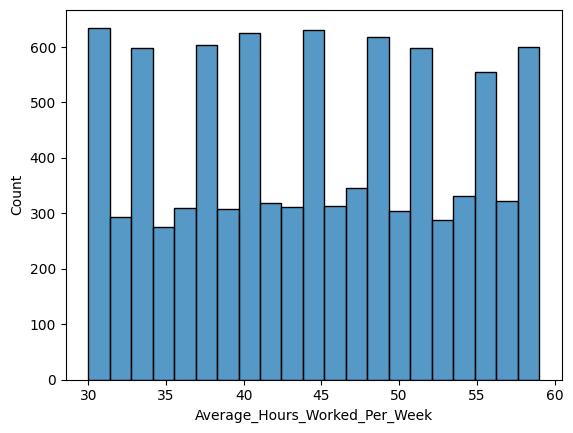

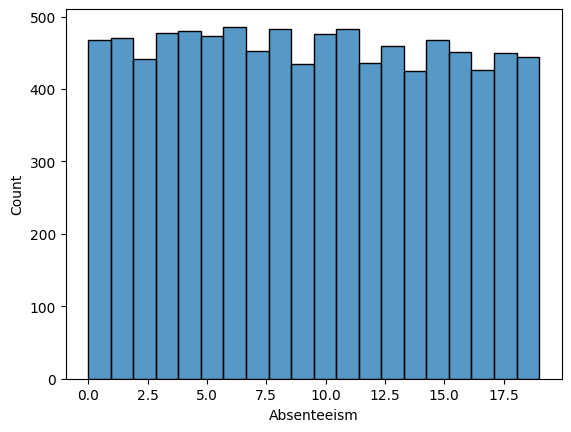

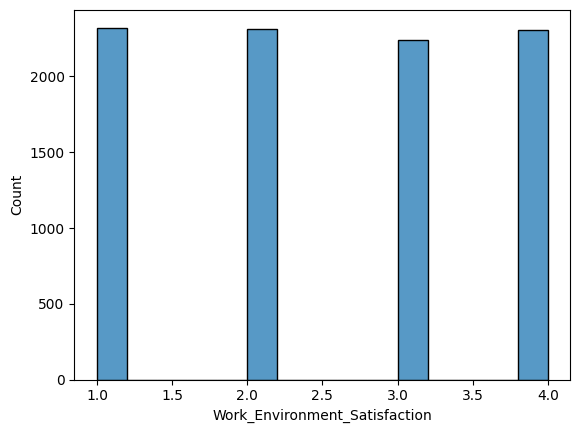

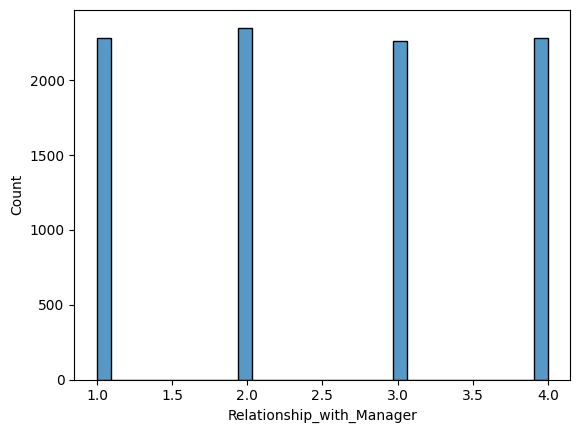

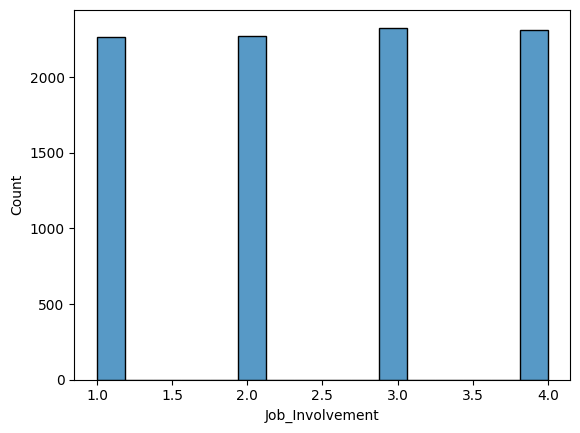

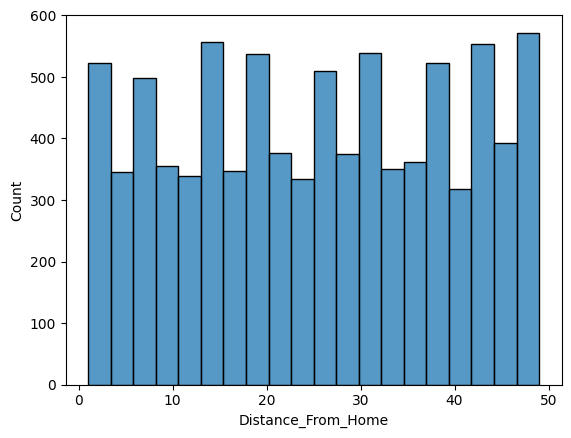

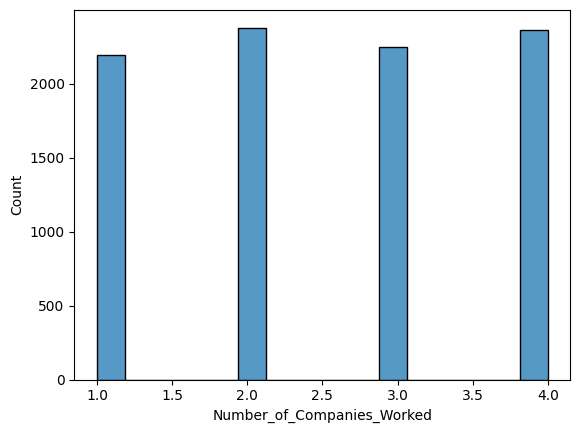

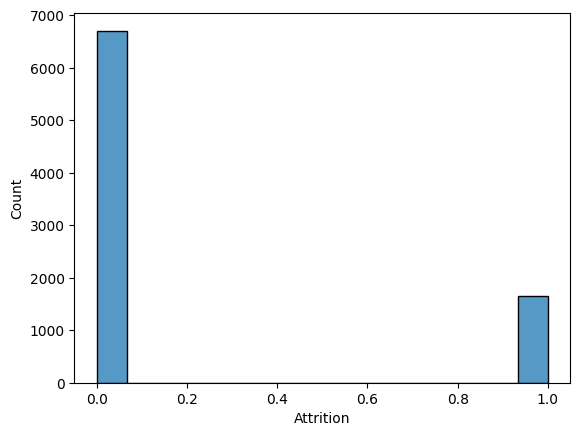

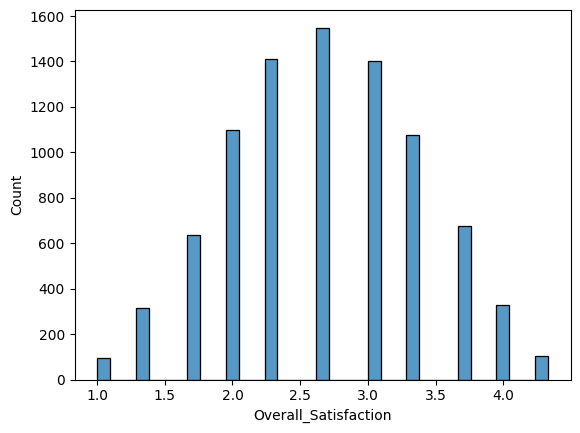

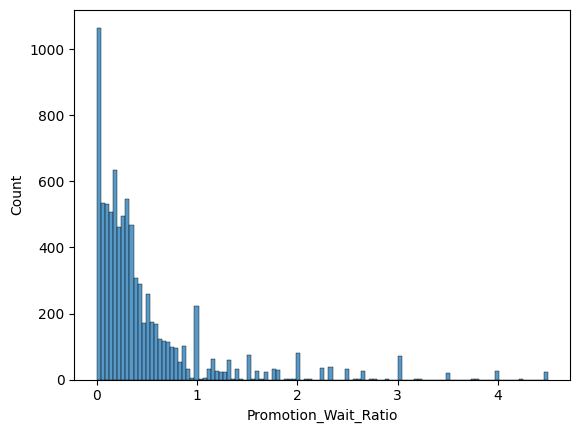

In [47]:
for col in df.select_dtypes('number').columns:
  plt.figure()
  sns.histplot(df[col])

## Apply Log Transformation to Monthly Income

In [48]:
df["Monthly_Income"]=np.log1p(df["Monthly_Income"])

/tmp/ipykernel_5521/3393671314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Monthly_Income"]=np.log1p(df["Monthly_Income"])


## Handle Outliers in Monthly Income (IQR Method)

In [49]:
Q1=df["Monthly_Income"].quantile(0.25)
Q3=df["Monthly_Income"].quantile(0.75)
IQR=Q3-Q1
Lower=Q1-1.5*IQR
upper=Q3+1*IQR
df["Monthly_Income"]=np.where(df["Monthly_Income"]<Lower,Lower,df["Monthly_Income"])
df["Monthly_Income"]=np.where(df["Monthly_Income"]>upper,upper,df["Monthly_Income"])

/tmp/ipykernel_5521/342563375.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Monthly_Income"]=np.where(df["Monthly_Income"]<Lower,Lower,df["Monthly_Income"])
/tmp/ipykernel_5521/342563375.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Monthly_Income"]=np.where(df["Monthly_Income"]>upper,upper,df["Monthly_Income"])


## Calculate Income Per Job Level

In [50]:
df['Income_Per_Level'] = (
    df['Monthly_Income'] /
    (df['Job_Level'] + 1)
)

/tmp/ipykernel_5521/832245390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Income_Per_Level'] = (


# Round Calculated Features

In [51]:
df['Income_Per_Level'] = df['Income_Per_Level'].round(2)

/tmp/ipykernel_5521/243386321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Income_Per_Level'] = df['Income_Per_Level'].round(2)


## Visualize Numerical Distributions After Outlier Handling

/tmp/ipykernel_5521/1006217207.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


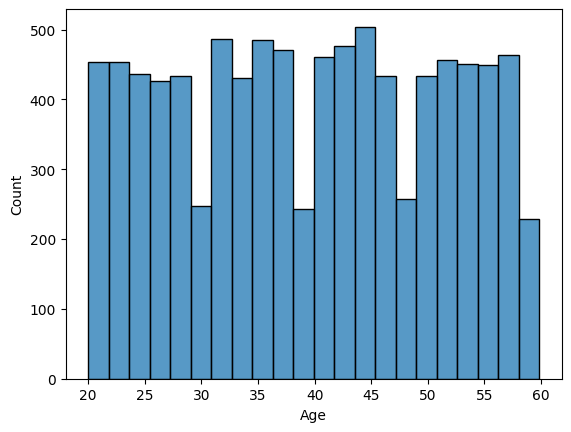

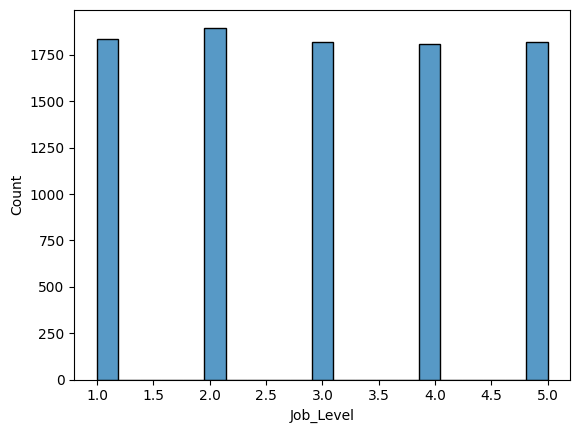

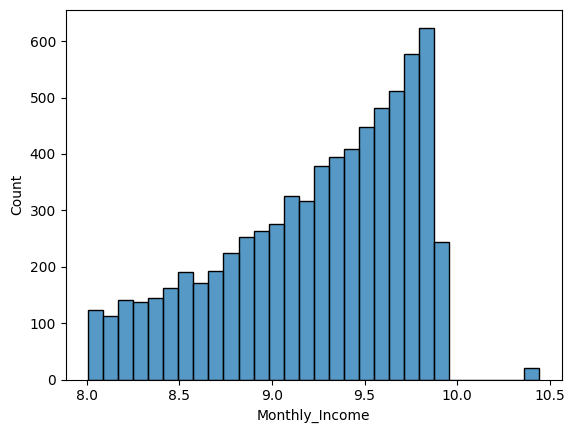

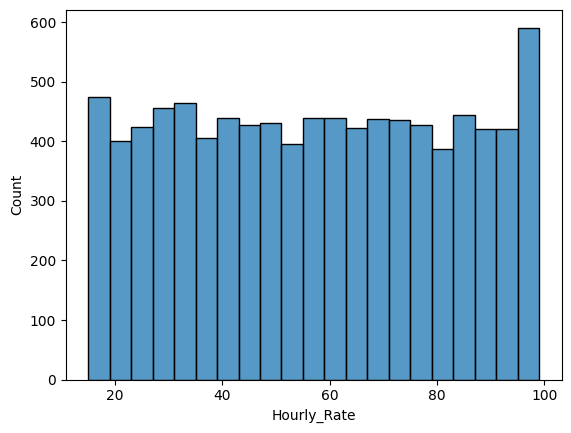

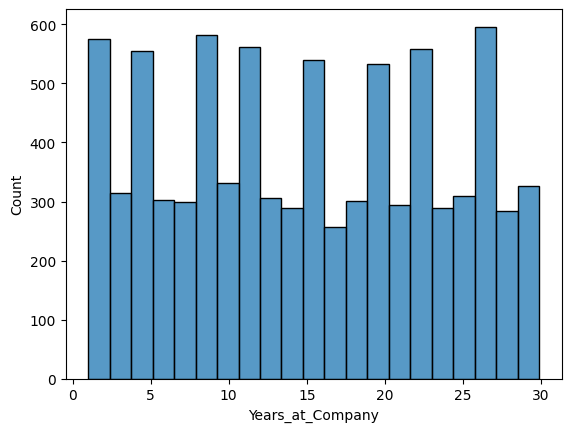

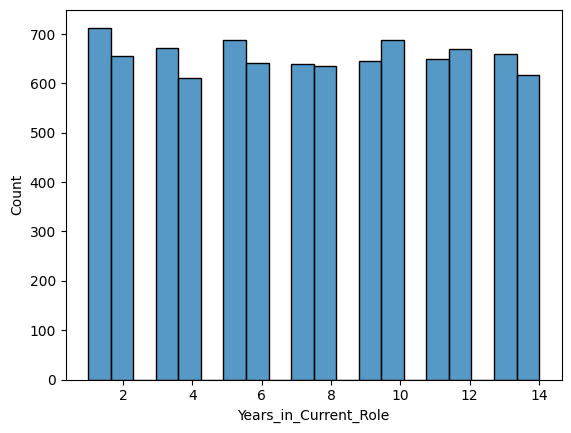

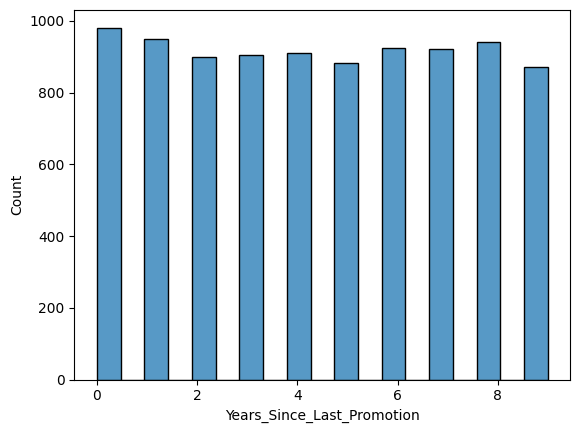

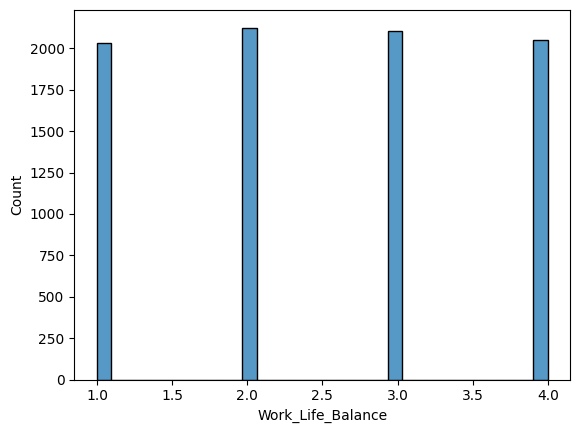

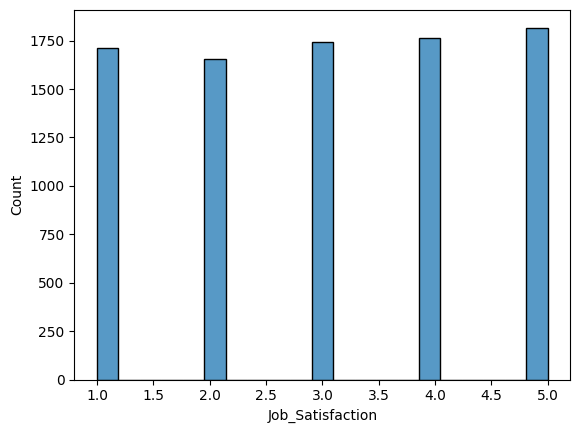

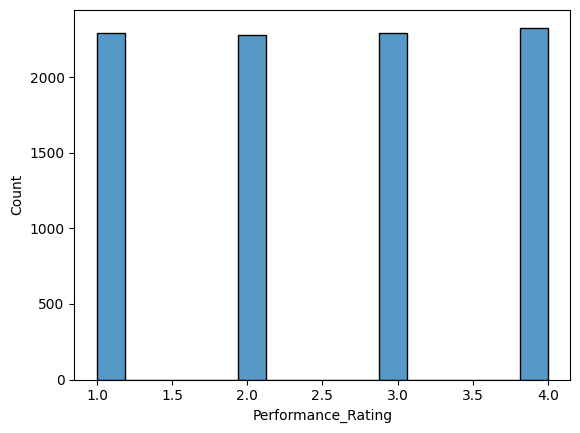

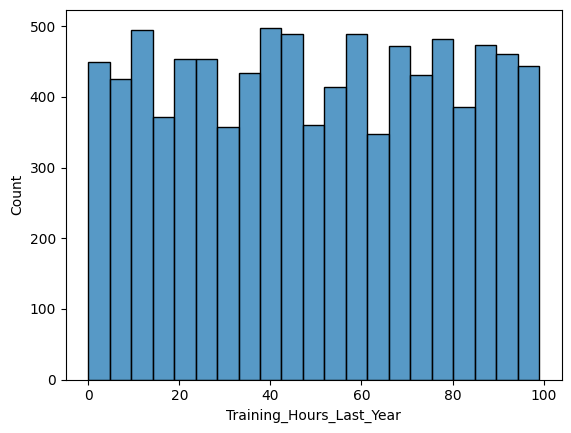

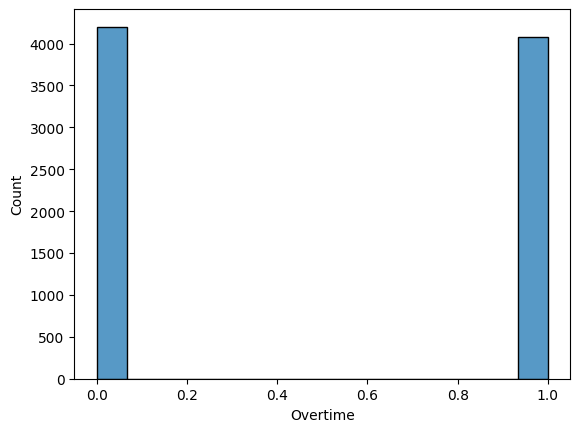

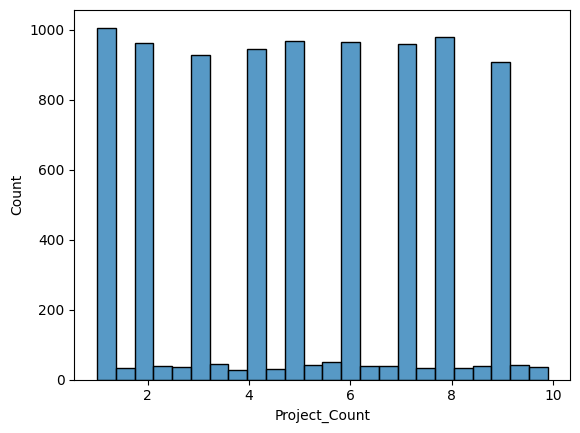

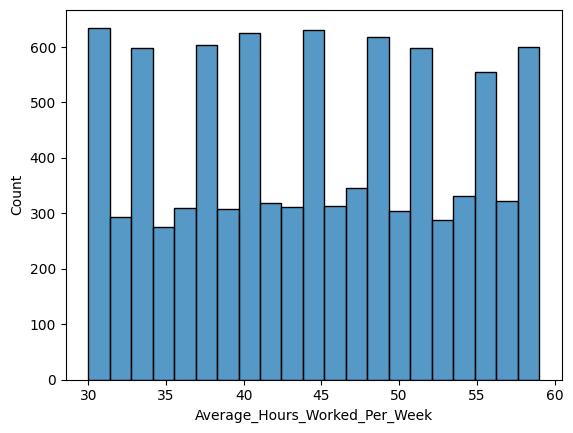

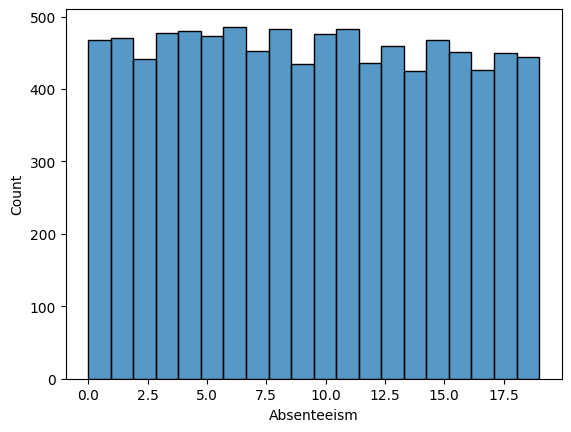

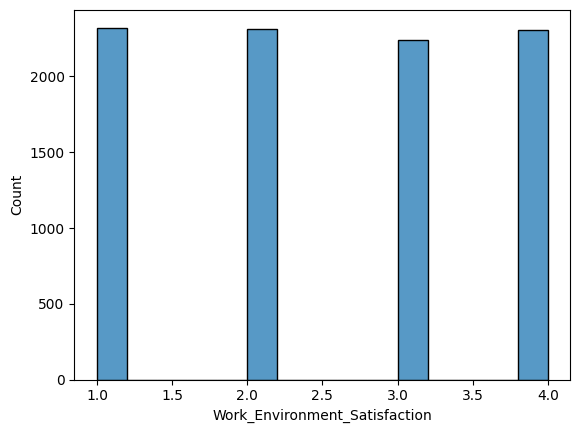

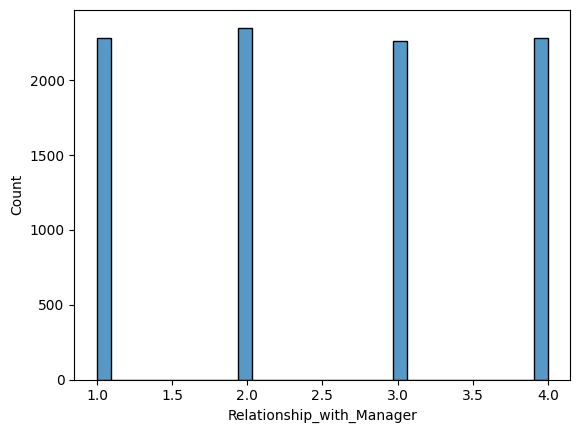

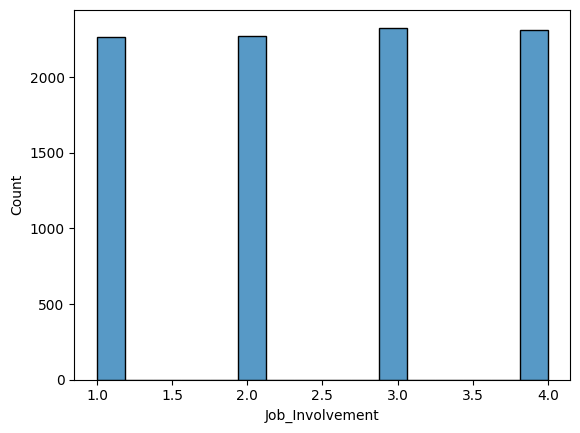

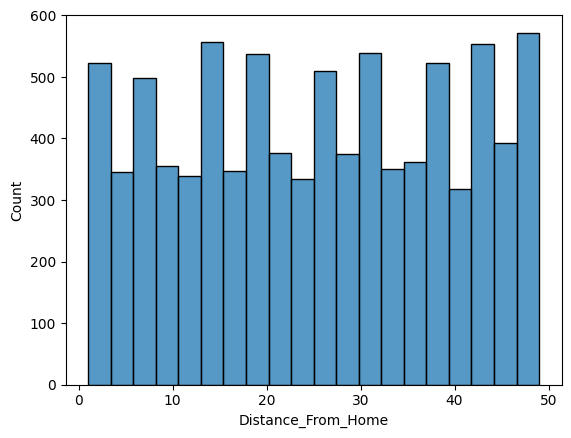

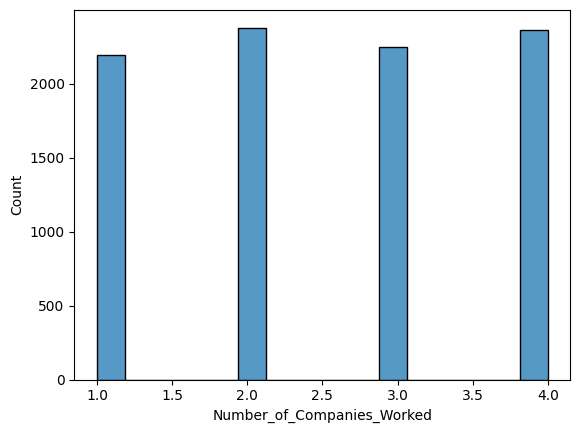

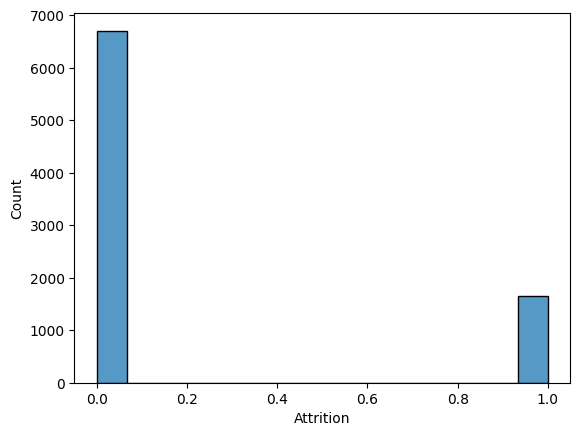

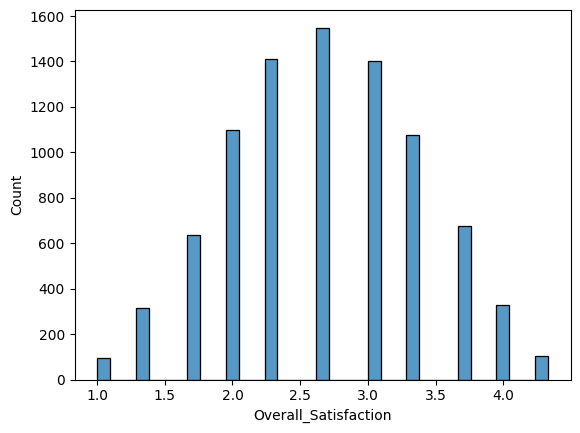

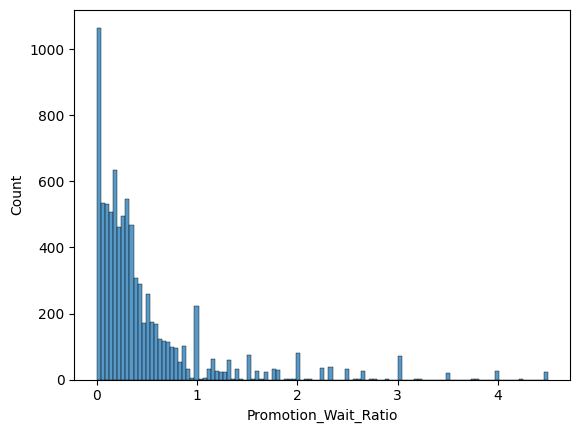

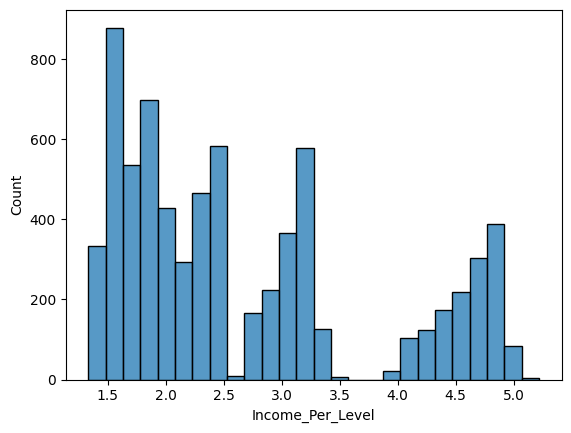

In [52]:
for col in df.select_dtypes('number').columns:
  plt.figure()
  sns.histplot(df[col])

## Visualize Categorical Distributions

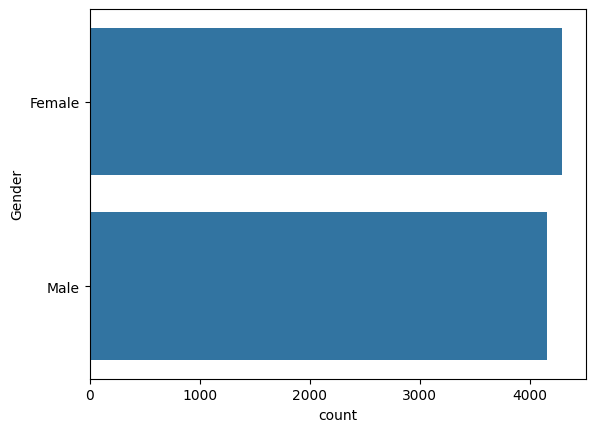

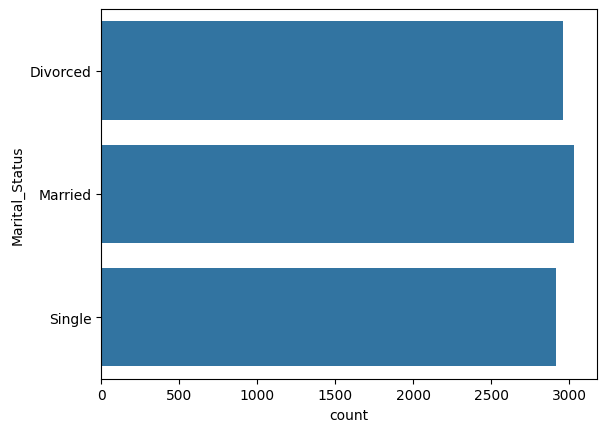

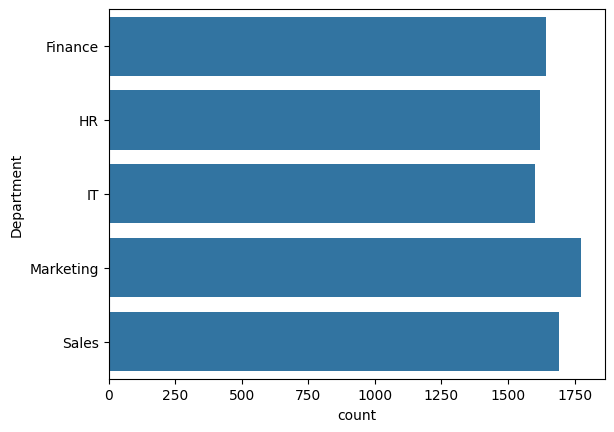

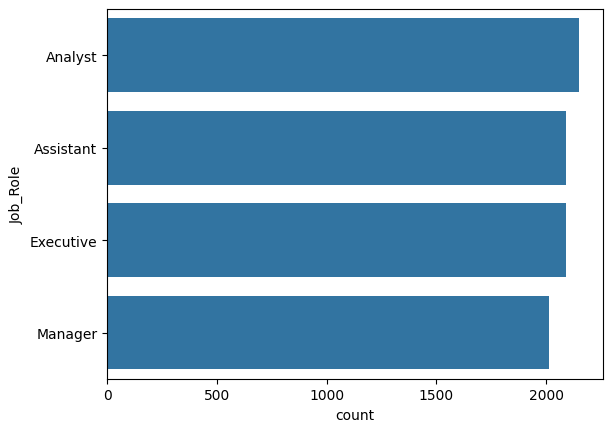

In [53]:
for col in df.select_dtypes('category').columns:
  plt.figure()
  sns.countplot(df[col])

## Numerical Feature Distributions by Attrition

/tmp/ipykernel_5521/3971385665.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


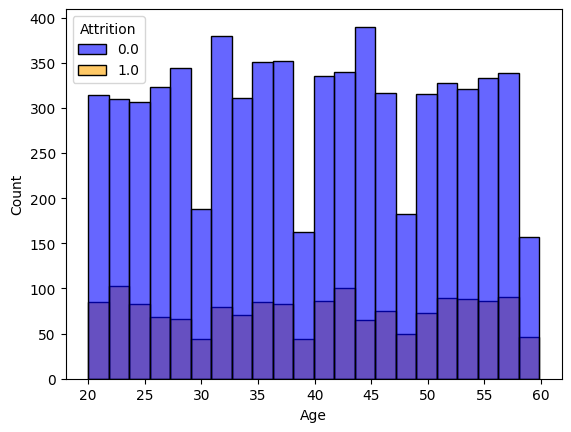

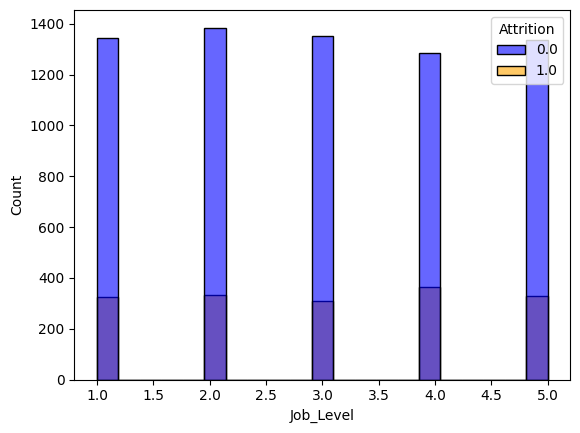

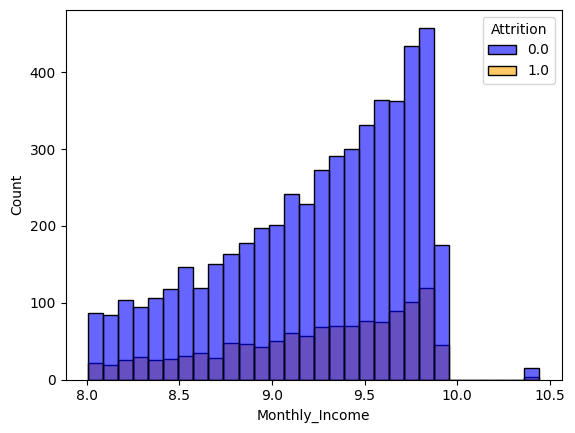

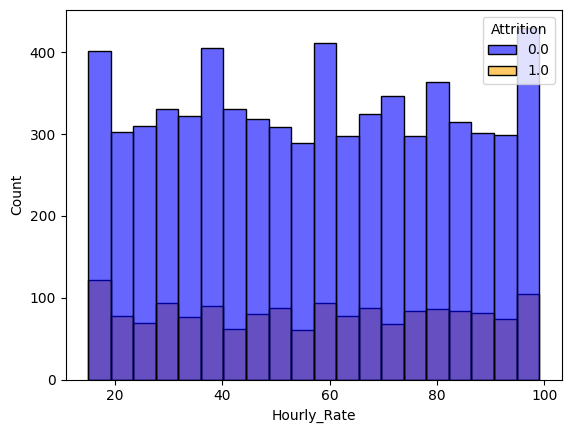

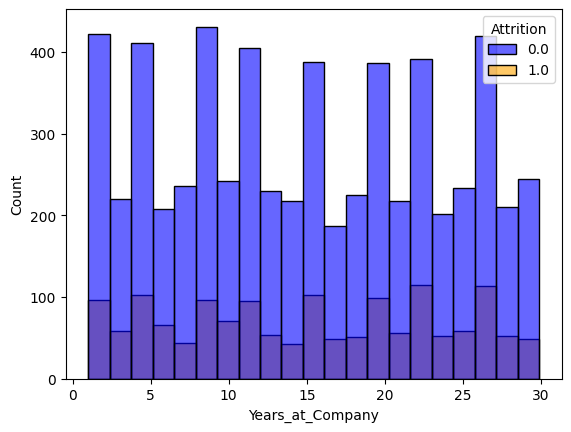

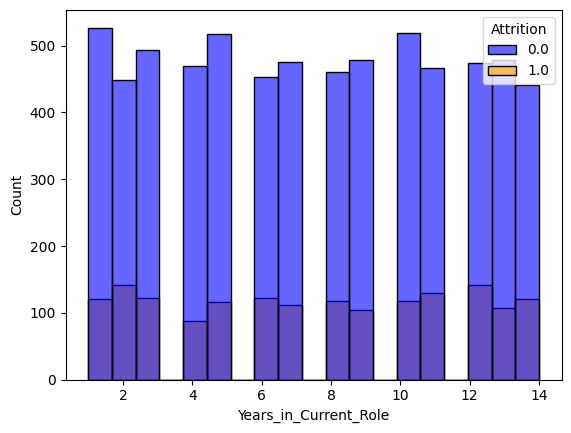

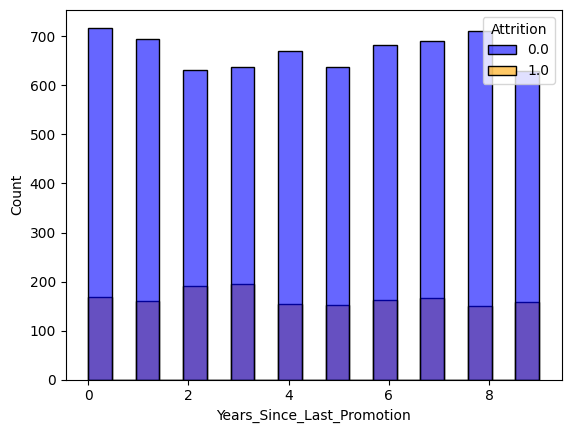

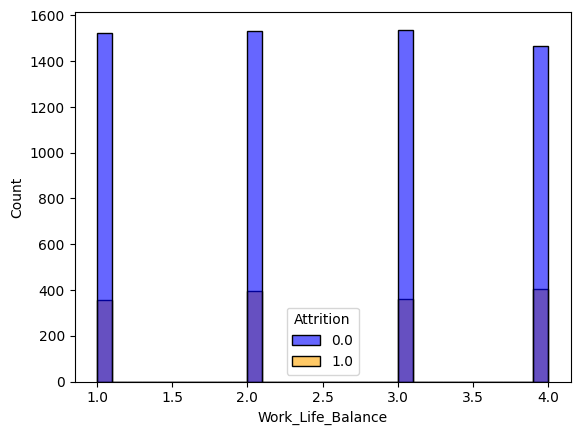

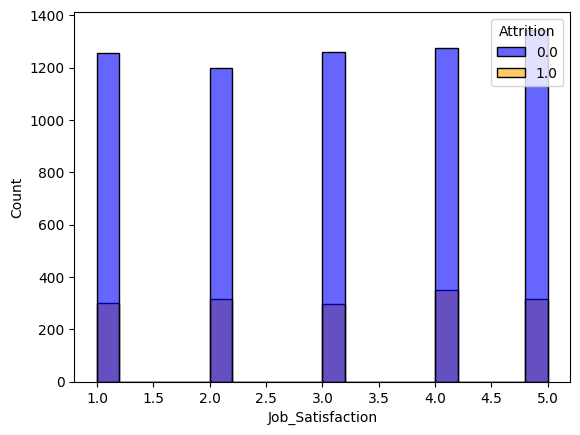

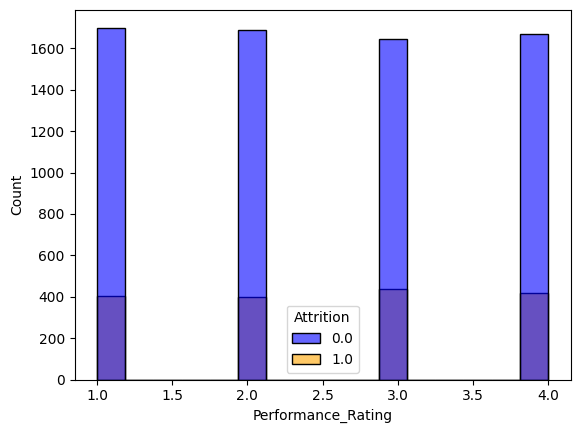

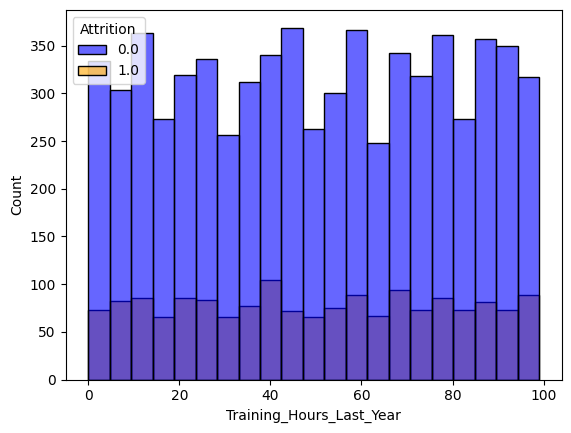

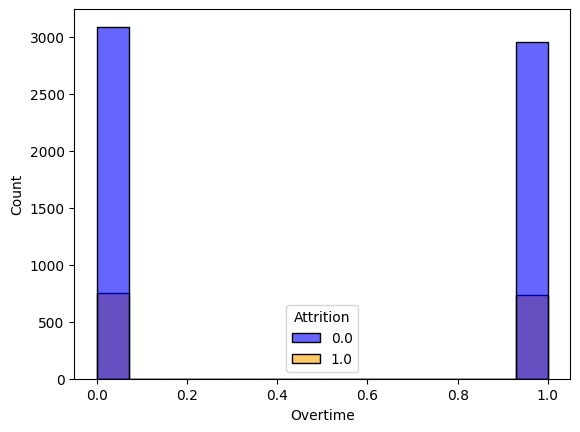

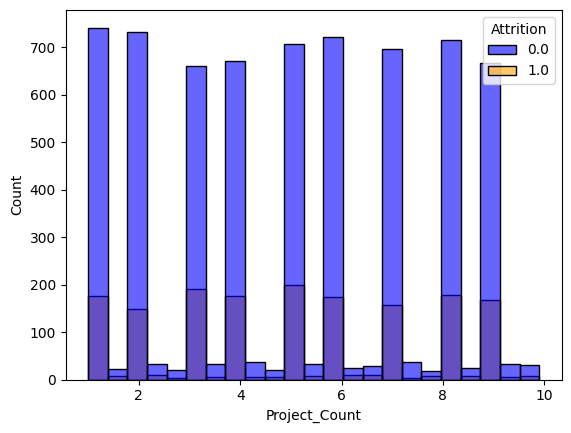

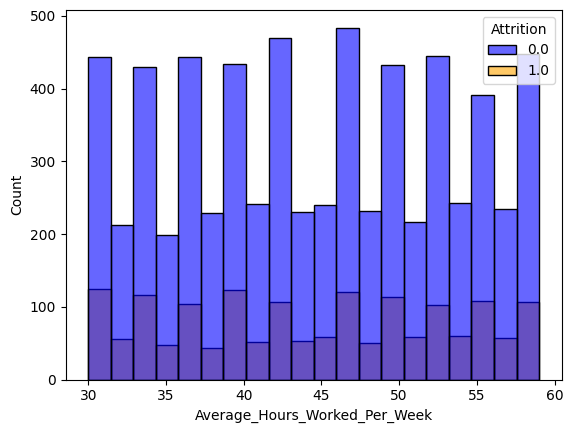

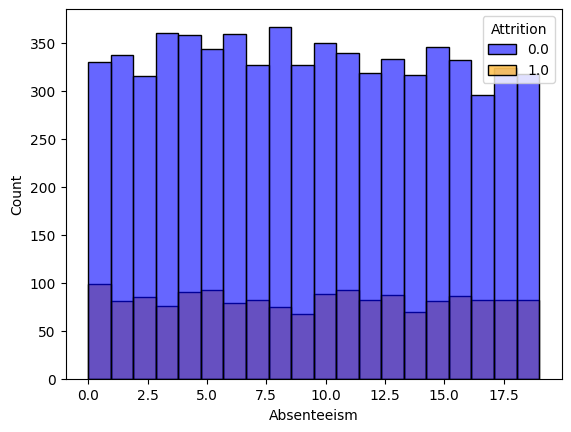

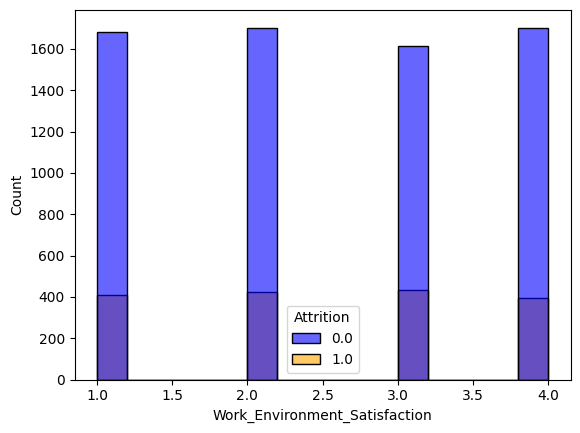

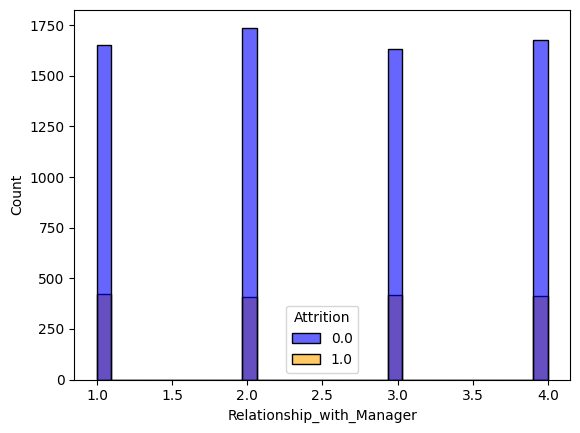

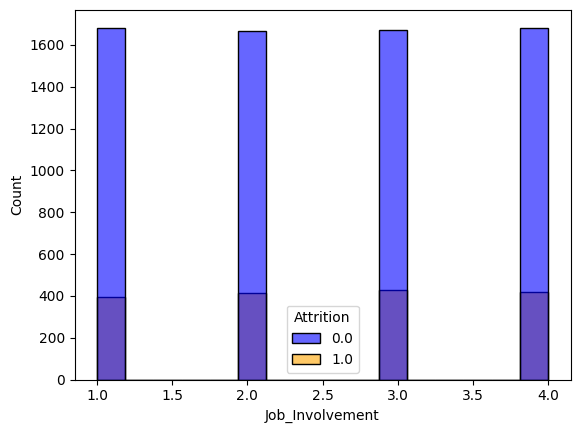

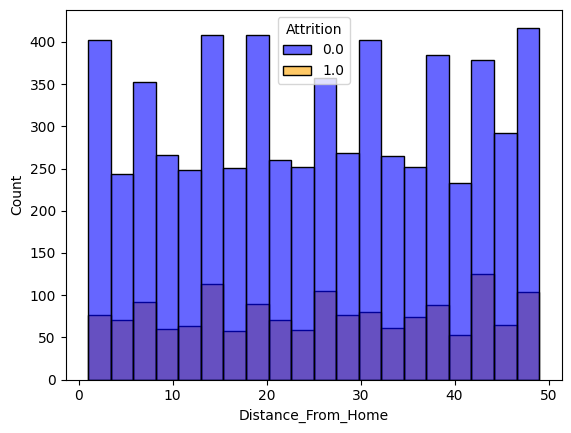

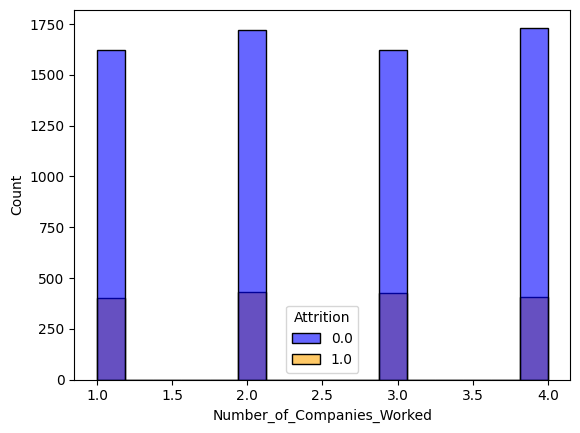

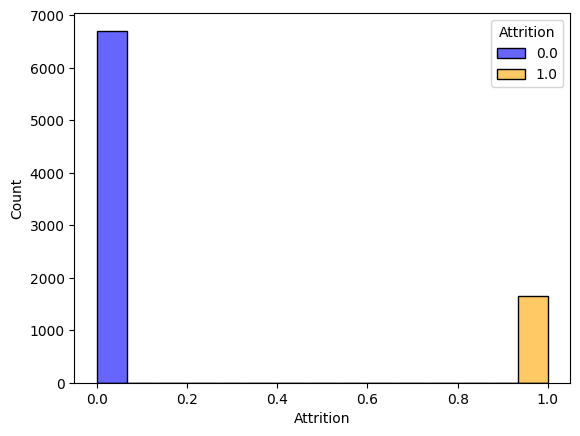

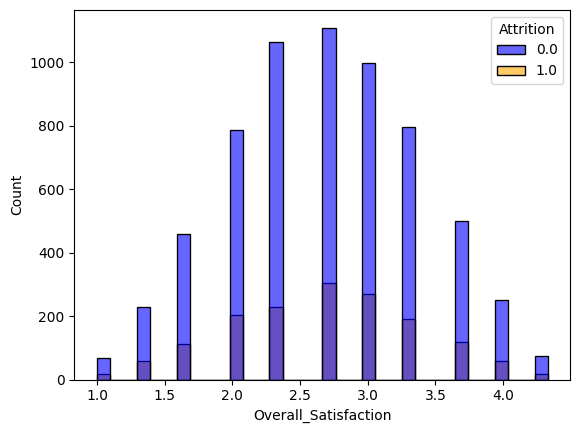

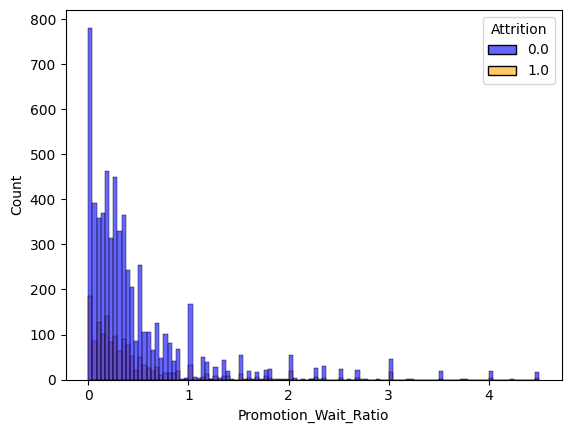

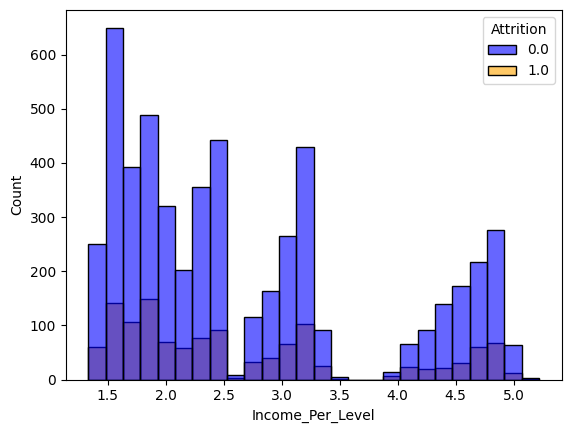

In [54]:
for col in df.select_dtypes('number').columns:
 plt.figure()
 sns.histplot(
    data=df,
    x=col,
    hue='Attrition',
    palette=['blue', 'orange'],
    alpha=0.6,
    edgecolor='black'
)

## Categorical Feature Distributions by Attrition

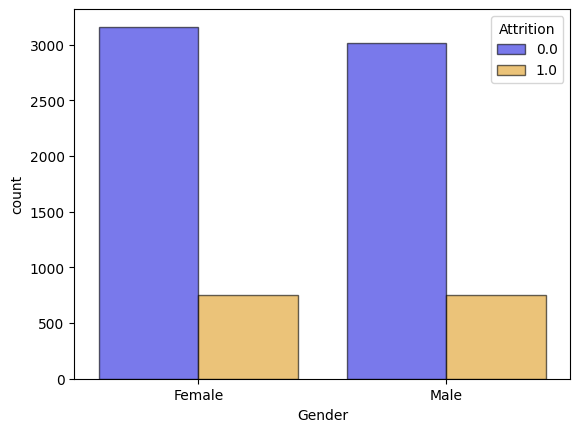

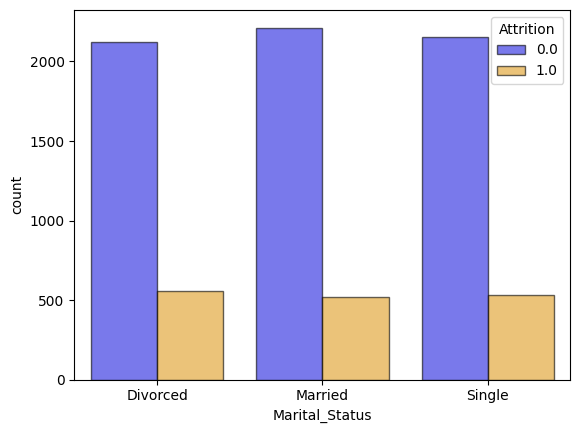

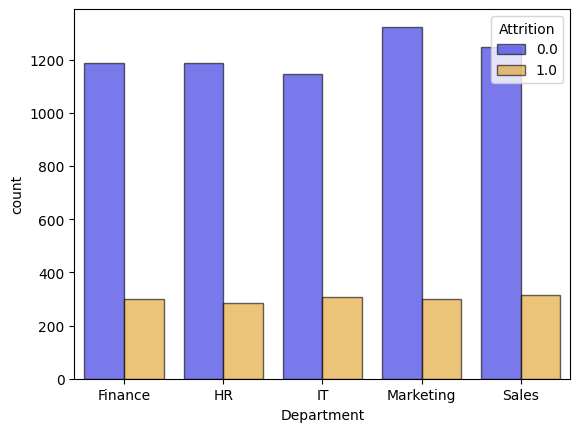

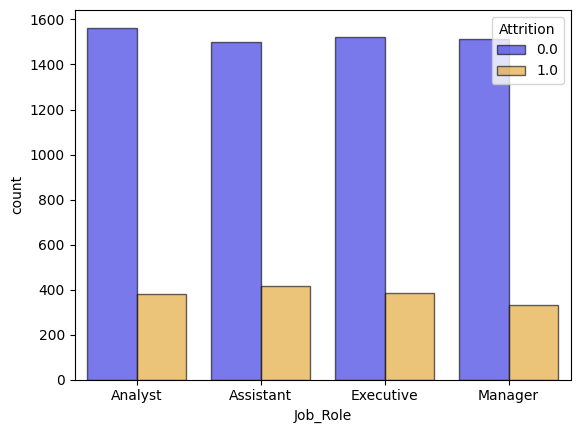

In [55]:
for col in df.select_dtypes('category').columns:
    plt.figure()
    sns.countplot(
        data=df,
        x=col,
        hue='Attrition',
        palette=['blue', 'orange'],
        alpha=0.6,
        edgecolor='black'
    )

## Pair Plot of Features by Attrition

In [56]:
sns.pairplot(df , hue = 'Attrition')

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f2c124a1080> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f2c1266e5c0> (for post_execute):


KeyboardInterrupt: 

## Correlation Heatmap of Numerical Features

In [ ]:
sns.heatmap(df.select_dtypes('number').corr() , annot=True )

## Monthly Income vs Job Satisfaction

<Axes: xlabel='Job_Satisfaction', ylabel='Monthly_Income'>

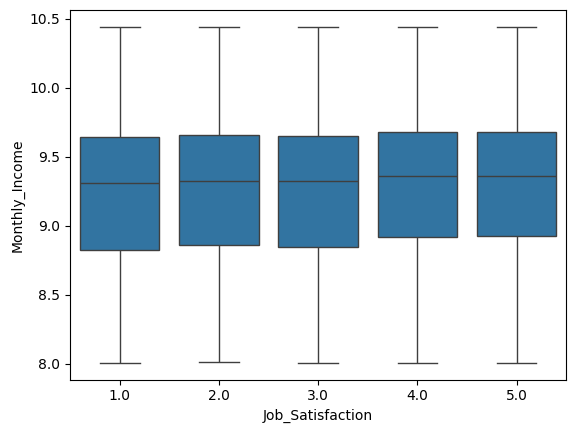

In [57]:
sns.boxplot(
    data=df,
    x='Job_Satisfaction',
    y='Monthly_Income'

)

## Job Satisfaction by Gender and Attrition

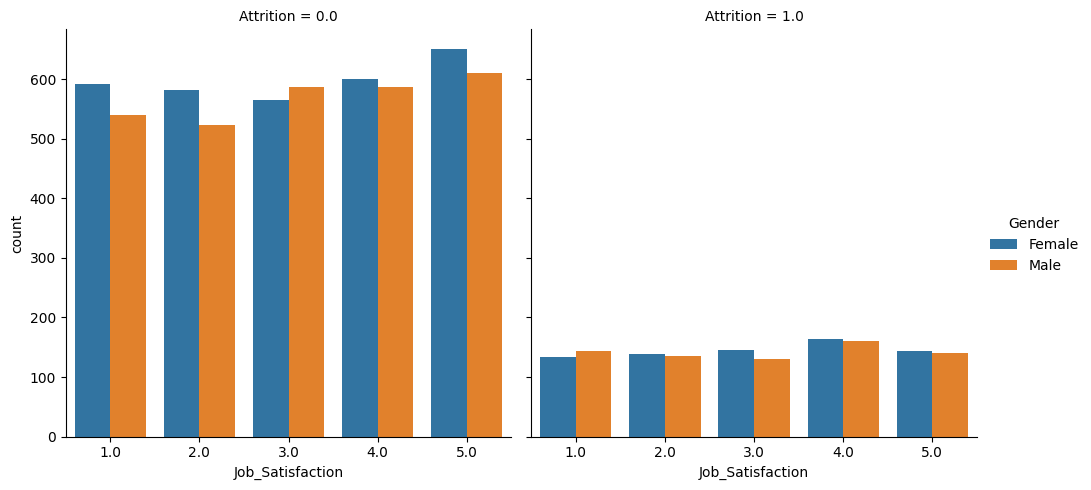

In [58]:
sns.catplot(
    data=df,
    x='Job_Satisfaction',
    hue='Gender',
    col='Attrition',
    kind='count'
)

## Performance Rating vs Companies Worked by Attrition

<Axes: xlabel='Performance_Rating', ylabel='Number_of_Companies_Worked'>

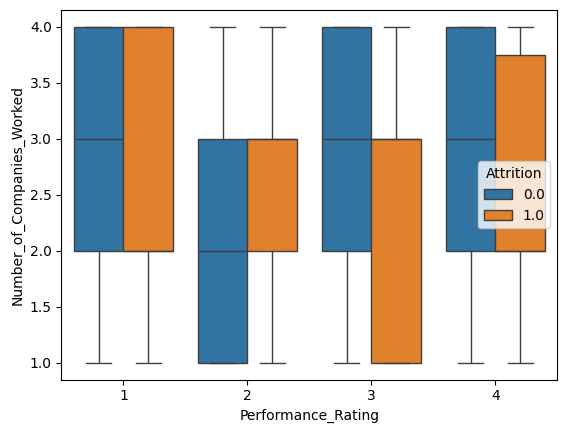

In [59]:
sns.boxplot(
    data=df,
    x='Performance_Rating',
    y='Number_of_Companies_Worked',
    hue='Attrition'
)

## Project Count vs Average Hours Worked by Attrition

<Axes: xlabel='Project_Count', ylabel='Average_Hours_Worked_Per_Week'>

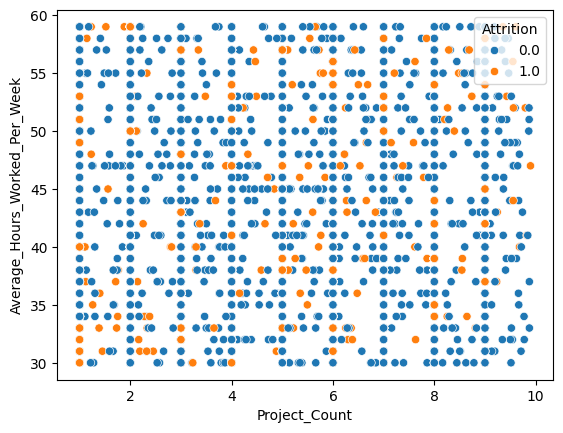

In [60]:
sns.scatterplot(
    data=df,
    x='Project_Count',
    y='Average_Hours_Worked_Per_Week',
    hue='Attrition'

)

## Job Satisfaction vs Age by Attrition

<Axes: xlabel='Job_Satisfaction', ylabel='Age'>

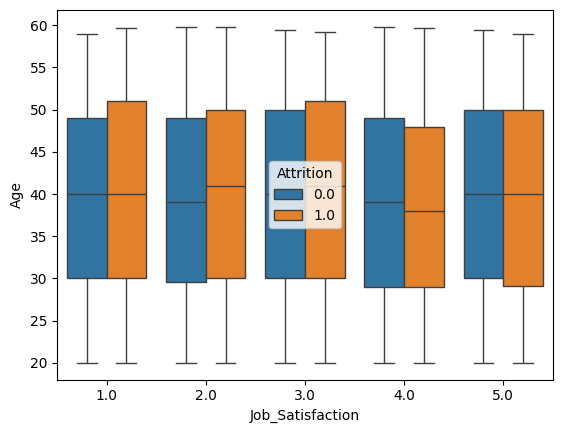

In [61]:
sns.boxplot(
    data=df,
    x='Job_Satisfaction',
    y='Age',
    hue='Attrition'
)

## Age vs Years at Company by Attrition

<Axes: xlabel='Age', ylabel='Years_at_Company'>

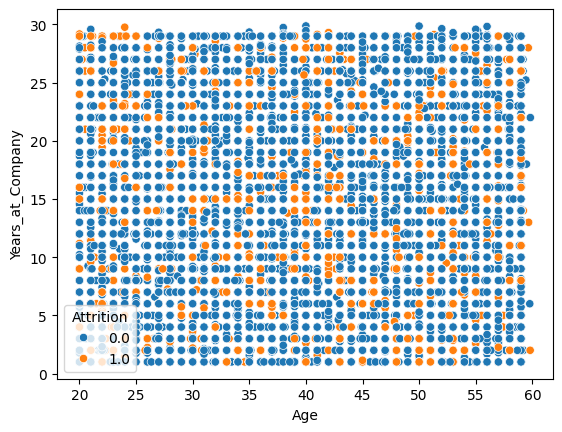

In [62]:
sns.scatterplot(

                data=df,
                x='Age',
                y='Years_at_Company',
                hue='Attrition'


)

## Relationship with Manager vs Work Environment Satisfaction by Attrition

<Axes: xlabel='Relationship_with_Manager', ylabel='Work_Environment_Satisfaction'>

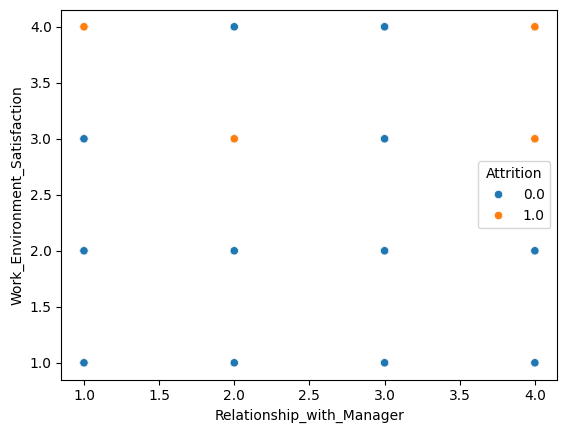

In [63]:
sns.scatterplot(

                data=df,
                x='Relationship_with_Manager',
                y='Work_Environment_Satisfaction',
                hue='Attrition'


)

## Department Distribution by Gender

<Axes: xlabel='Department', ylabel='count'>

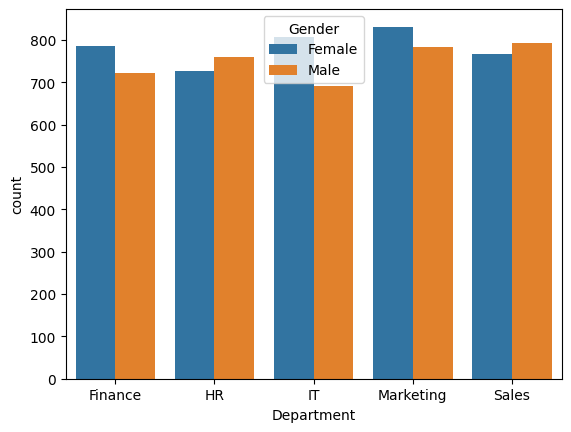

In [64]:
sns.countplot(
    data=df,
    x='Department',
    hue='Gender'

)

## Department vs Job Satisfaction by Attrition

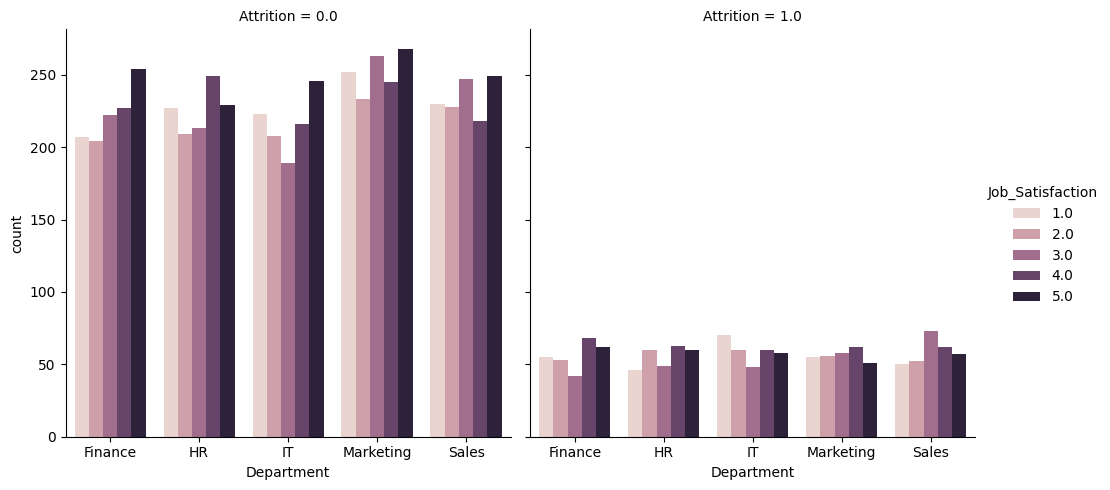

In [65]:
sns.catplot(
    data=df,
    x='Department',
    hue='Job_Satisfaction',
    col='Attrition',
    kind='count'

)

## Model Preparation

## Import Machine Learning Libraries

In [91]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , OrdinalEncoder , MinMaxScaler , StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split , GridSearchCV , cross_validate , RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer , KNNImputer
from sklearn.pipeline import Pipeline , make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier , VotingClassifier , AdaBoostClassifier, GradientBoostingClassifier , BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score
from sklearn.naive_bayes import GaussianNB

## Define Features (X) and Target (y)

In [92]:
x=df.drop(['Attrition'] , axis=1)
y=df['Attrition']

## Split Data into Training and Testing Sets

In [93]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42, stratify=y)

## Define Numerical and Categorical Features

In [94]:
num_data=['Age', 'Job_Level' ,  'Monthly_Income'   , 'Hourly_Rate' , 'Years_at_Company' , 'Years_in_Current_Role' , 'Years_Since_Last_Promotion' , 'Work_Life_Balance' , 'Job_Satisfaction' , 'Performance_Rating' , 'Training_Hours_Last_Year' , 'Project_Count' , 'Distance_From_Home' , 'Absenteeism'  , 'Average_Hours_Worked_Per_Week' , 'Work_Environment_Satisfaction' , 'Relationship_with_Manager' , 'Job_Involvement' ,
    'Number_of_Companies_Worked', 'Overtime', 'Overall_Satisfaction', 'Promotion_Wait_Ratio', 'Income_Per_Level']
cat_data=['Gender' , 'Marital_Status' , 'Department' , 'Job_Role']

## Create Numerical Preprocessing Pipeline

In [95]:
knn_imputer=KNNImputer()
num_pipeline=Pipeline([
    ('Knn_Imputer',knn_imputer),
    ('StandardScaler',StandardScaler())

])
num_pipeline

Pipeline(steps=[('Knn_Imputer', KNNImputer()),
                ('StandardScaler', StandardScaler())])

## Create Categorical Preprocessing Pipeline

In [96]:
ohe=OneHotEncoder()
cat_pipeline=Pipeline([
  ('OneHotEncoder', OneHotEncoder())

])
cat_pipeline

Pipeline(steps=[('OneHotEncoder', OneHotEncoder())])

## Create Column Transformer for Preprocessing

In [97]:
preprocessing = ColumnTransformer(transformers=[
    ('Num pipeline',num_pipeline,num_data),
    ('OHE pipeline',cat_pipeline,cat_data)

], remainder='passthrough'


  )
preprocessing

ColumnTransformer(remainder='passthrough',
                  transformers=[('Num pipeline',
                                 Pipeline(steps=[('Knn_Imputer', KNNImputer()),
                                                 ('StandardScaler',
                                                  StandardScaler())]),
                                 ['Age', 'Job_Level', 'Monthly_Income',
                                  'Hourly_Rate', 'Years_at_Company',
                                  'Years_in_Current_Role',
                                  'Years_Since_Last_Promotion',
                                  'Work_Life_Balance', 'Job_Satisfaction',
                                  'Performance_Rating',
                                  'Training_Hour...
                                  'Distance_From_Home', 'Absenteeism',
                                  'Average_Hours_Worked_Per_Week',
                                  'Work_Environment_Satisfaction',
                                  'Relationship_with_Manager',
                                  'Job_Involvement',
                                  'Number_of_Companies_Worked', 'Overtime',
                                  'Overall_Satisfaction',
                                  'Promotion_Wait_Ratio', 'Income_Per_Level']),
                                ('OHE pipeline',
                                 Pipeline(steps=[('OneHotEncoder',
                                                  OneHotEncoder())]),
                                 ['Gender', 'Marital_Status', 'Department',
                                  'Job_Role'])])

## Apply Preprocessing to Training and Test Data

In [98]:
x_train_preprocessed=preprocessing.fit_transform(x_train)
x_test_preprocessed=preprocessing.fit_transform(x_test)

## Baseline Model Training and Evaluation

## Define Logistic Regression Model Pipeline

In [99]:
model= Pipeline([
    ('preprocessing',preprocessing),
    ('Classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

## Train Logistic Regression Model (Full Pipeline)

In [ ]:
model.fit(x_train,y_train)

## Train Logistic Regression (Preprocessed Data)

In [ ]:
lr=LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr.fit(x_train_preprocessed,y_train)
print("Lr Train:", lr.score(x_train_preprocessed,y_train) )
print("lr test:" ,lr.score(x_test_preprocessed, y_test ))

## Train K-Nearest Neighbors Classifier

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights='distance',
    metric='manhattan'
)
knn.fit(x_train_preprocessed,y_train)
print("knn train:",knn.score(x_train_preprocessed,y_train))
print("knn test:", knn.score(x_test_preprocessed,y_test))

## Train Random Forest Classifier

In [ ]:
rf= RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42,max_depth=5 ,min_samples_leaf=5)
rf.fit(x_train_preprocessed, y_train)
print("rf  train:", rf.score(x_train_preprocessed, y_train))
print("rf test" , rf.score(x_test_preprocessed , y_test))

## Train AdaBoost Classifier

In [ ]:
adaboost = AdaBoostClassifier(n_estimators=200, random_state=42)
adaboost.fit(x_train_preprocessed, y_train)
print("AdaBoost train:", adaboost.score(x_train_preprocessed, y_train))
print("AdaBoost test:", adaboost.score(x_test_preprocessed, y_test))

## Train Decision Tree Classifier

In [ ]:
dtc = DecisionTreeClassifier(class_weight='balanced', random_state=42 , max_depth=5 ,min_samples_leaf=5)
dtc.fit(x_train_preprocessed, y_train)
print("Decision Tree train:", dtc.score(x_train_preprocessed, y_train))
print("Decision Tree test:", dtc.score(x_test_preprocessed, y_test))

## Train Gradient Boosting Classifier

In [ ]:
gbc = GradientBoostingClassifier(n_estimators=200, random_state=42)
gbc.fit(x_train_preprocessed, y_train)
print("Gradient Boosting train:", gbc.score(x_train_preprocessed, y_train))
print("Gradient Boosting test:", gbc.score(x_test_preprocessed, y_test))

## Evaluate Logistic Regression Performance

In [ ]:
y_pred_lr = lr.predict(x_test_preprocessed)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Logistic Regression Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate K-Nearest Neighbors Performance

In [ ]:
y_pred_knn = knn.predict(x_test_preprocessed)
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("KNN Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate Random Forest Performance

In [ ]:
y_pred_rf = rf.predict(x_test_preprocessed)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate AdaBoost Performance

In [ ]:
y_pred_adaboost = adaboost.predict(x_test_preprocessed)
print("AdaBoost Classification Report:")
print(classification_report(y_test, y_pred_adaboost))
print("AdaBoost Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_adaboost), annot=True, fmt='d', cmap='Blues')
plt.title('AdaBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate Decision Tree Performance

In [ ]:
y_pred_dtc = dtc.predict(x_test_preprocessed)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dtc))
print("Decision Tree Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_dtc), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate Gradient Boosting Performance

In [ ]:
y_pred_gbc = gbc.predict(x_test_preprocessed)
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gbc))
print("Gradient Boosting Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_gbc), annot=True, fmt='d', cmap='Blues')
plt.title('Gradient Boosting Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Data Resampling (SMOTE)

## Resample Training Data with SMOTE

In [ ]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_preprocessed, y_train)

print("Shape of original training data:", x_train_preprocessed.shape, y_train.shape)
print("Shape of resampled training data:", x_train_smote.shape, y_train_smote.shape)
print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

## Model Training and Evaluation (with SMOTE)

## Train Models with SMOTE Resampled Data

In [ ]:
print('***Re-training models with SMOTE resampled data ***')


lr_smote = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_smote.fit(x_train_smote, y_train_smote)
print("Logistic Regression (SMOTE) Train:", lr_smote.score(x_train_smote, y_train_smote))
print("Logistic Regression (SMOTE) Test:", lr_smote.score(x_test_preprocessed, y_test))


knn_smote = KNeighborsClassifier(n_neighbors=15, weights='distance', metric='manhattan')
knn_smote.fit(x_train_smote, y_train_smote)
print("KNN (SMOTE) Train:", knn_smote.score(x_train_smote, y_train_smote))
print("KNN (SMOTE) Test:", knn_smote.score(x_test_preprocessed, y_test))


rf_smote = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=5, min_samples_leaf=5)
rf_smote.fit(x_train_smote, y_train_smote)
print("Random Forest (SMOTE) Train:", rf_smote.score(x_train_smote, y_train_smote))
print("Random Forest (SMOTE) Test:", rf_smote.score(x_test_preprocessed, y_test))


adaboost_smote = AdaBoostClassifier(n_estimators=200, random_state=42)
adaboost_smote.fit(x_train_smote, y_train_smote)
print("AdaBoost (SMOTE) Train:", adaboost_smote.score(x_train_smote, y_train_smote))
print("AdaBoost (SMOTE) Test:", adaboost_smote.score(x_test_preprocessed, y_test))


dtc_smote = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=5, min_samples_leaf=5)
dtc_smote.fit(x_train_smote, y_train_smote)
print("Decision Tree (SMOTE) Train:", dtc_smote.score(x_train_smote, y_train_smote))
print("Decision Tree (SMOTE) Test:", dtc_smote.score(x_test_preprocessed, y_test))


gbc_smote = GradientBoostingClassifier(n_estimators=200, random_state=42)
gbc_smote.fit(x_train_smote, y_train_smote)
print("Gradient Boosting (SMOTE) Train:", gbc_smote.score(x_train_smote, y_train_smote))
print("Gradient Boosting (SMOTE) Test:", gbc_smote.score(x_test_preprocessed, y_test))

## Evaluate Logistic Regression (SMOTE) Performance

In [ ]:
y_pred_lr_smote = lr_smote.predict(x_test_preprocessed)
print("Logistic Regression (SMOTE) Classification Report:")
print(classification_report(y_test, y_pred_lr_smote))
print("Logistic Regression (SMOTE) Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_lr_smote), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression (SMOTE) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate K-Nearest Neighbors (SMOTE) Performance

In [ ]:
y_pred_knn_smote = knn_smote.predict(x_test_preprocessed)
print("KNN (SMOTE) Classification Report:")
print(classification_report(y_test, y_pred_knn_smote))
print("KNN (SMOTE) Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_knn_smote), annot=True, fmt='d', cmap='Blues')
plt.title('KNN (SMOTE) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate Random Forest (SMOTE) Performance

In [ ]:
y_pred_rf_smote = rf_smote.predict(x_test_preprocessed)
print("Random Forest (SMOTE) Classification Report:")
print(classification_report(y_test, y_pred_rf_smote))
print("Random Forest (SMOTE) Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_rf_smote), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest (SMOTE) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate AdaBoost (SMOTE) Performance

In [ ]:
y_pred_adaboost_smote = adaboost_smote.predict(x_test_preprocessed)
print("AdaBoost (SMOTE) Classification Report:")
print(classification_report(y_test, y_pred_adaboost_smote))
print("AdaBoost (SMOTE) Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_adaboost_smote), annot=True, fmt='d', cmap='Blues')
plt.title('AdaBoost (SMOTE) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate Decision Tree (SMOTE) Performance

In [ ]:
y_pred_dtc_smote = dtc_smote.predict(x_test_preprocessed)
print("Decision Tree (SMOTE) Classification Report:")
print(classification_report(y_test, y_pred_dtc_smote))
print("Decision Tree (SMOTE) Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_dtc_smote), annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree (SMOTE) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Evaluate Gradient Boosting (SMOTE) Performance

In [ ]:
y_pred_gbc_smote = gbc_smote.predict(x_test_preprocessed)
print("Gradient Boosting (SMOTE) Classification Report:")
print(classification_report(y_test, y_pred_gbc_smote))
print("Gradient Boosting (SMOTE) Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_gbc_smote), annot=True, fmt='d', cmap='Blues')
plt.title('Gradient Boosting (SMOTE) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Cross-Validation

## Cross-Validate Model (Full Pipeline)

In [ ]:
cv_result= cross_validate(model , x, y ,cv=5 , scoring='f1' , return_train_score=True, n_jobs=-1)

## Display Cross-Validation Results

In [ ]:
cv_result

## Calculate Mean Train F1 Score

In [ ]:
cv_result['train_score'].mean()

## Calculate Mean Test F1 Score

In [ ]:
cv_result['test_score'].mean()

## Feature Selection

## Cross-Validate Individual Models

In [ ]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Decision Tree": dtc
}

for name, model in models.items():
    cv_result = cross_validate(
        model,
        x_train_preprocessed,
        y_train,
        cv=5,
        scoring='f1',
        return_train_score=True,
        n_jobs=-1
    )

    print(name)
    print("Train F1:", cv_result['train_score'].mean())
    print("Test F1:", cv_result['test_score'].mean())
    print("-" * 30)

## Import Feature Selection Libraries

In [ ]:
from sklearn.feature_selection import SelectFromModel, SequentialFeatureSelector

## Define Sequential Feature Selector Pipeline

In [ ]:
lr = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select=10,
    direction='forward',
    scoring='f1',
    cv=5,
    n_jobs=-1
)

model = make_pipeline(
    StandardScaler(),
    sfs,
    lr
)

## Train SFS Logistic Regression Model

In [ ]:
model.fit(x_train_preprocessed, y_train)

y_pred = model.predict(x_test_preprocessed)

print(classification_report(y_test, y_pred))

## Cross-Validate SFS Logistic Regression

In [ ]:
cv_result = cross_validate(
    model,
    x_train_preprocessed,
    y_train,
    cv=5,
    scoring='f1',
    return_train_score=True,
    n_jobs=-1
)

print("Train F1:", cv_result['train_score'].mean())
print("Test F1:", cv_result['test_score'].mean())

## Hyperparameter Tuning

## Hyperparameter Tuning for Logistic Regression

In [ ]:
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('preprocessing', preprocessing),
    ('logisticregression', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

lr_param = {
    'logisticregression__C': [0.1, 1, 10],
    'logisticregression__solver': ['liblinear', 'lbfgs']
}

lr_srch = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_param,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

lr_srch.fit(x_train, y_train)

print("Best Estimator:")
print(lr_srch.best_estimator_)
print("\nBest Cross-Validated F1:")
print(lr_srch.best_score_)
print("\nBest Params:")
print(lr_srch.best_params_)

## Model Comparison and Selection

## Evaluate Best Logistic Regression Model

In [ ]:
best_lr = lr_srch.best_estimator_

y_pred = best_lr.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, zero_division=0))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

## Compare Logistic Regression Models

In [ ]:
comparison_df = pd.DataFrame({

    'Model': [
        'Logistic Regression Baseline',
        'Logistic Regression Tuned'
    ],

    'F1 Score': [
        0.35,
        f1_score(y_test, y_pred, zero_division=0)
    ],

    'Recall': [
        0.57,
        recall_score(y_test, y_pred, zero_division=0)
    ]
})

comparison_df


Re-instantiate and re-train the baseline Logistic Regression model

In [ ]:

lr_baseline = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_baseline.fit(x_train_preprocessed, y_train)

## Comprehensive Model Comparison

In [ ]:
comparison_data = {
    'Model': [
        'Logistic Regression (Baseline)', 'KNN (Baseline)', 'Random Forest (Baseline)',
        'AdaBoost (Baseline)', 'Decision Tree (Baseline)', 'Gradient Boosting (Baseline)',
        'Logistic Regression (SMOTE)', 'KNN (SMOTE)', 'Random Forest (SMOTE)',
        'AdaBoost (SMOTE)', 'Decision Tree (SMOTE)', 'Gradient Boosting (SMOTE)',
        'Logistic Regression (Tuned)'
    ],
    'F1 Score (Class 1)': [
        f1_score(y_test, lr_baseline.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, knn.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, rf.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, adaboost.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, dtc.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, gbc.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, lr_smote.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, knn_smote.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, rf_smote.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, adaboost_smote.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, dtc_smote.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, gbc_smote.predict(x_test_preprocessed), zero_division=0),
        f1_score(y_test, best_lr.predict(x_test), zero_division=0)
    ],
    'Recall (Class 1)': [
        recall_score(y_test, lr_baseline.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, knn.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, rf.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, adaboost.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, dtc.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, gbc.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, lr_smote.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, knn_smote.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, rf_smote.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, adaboost_smote.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, dtc_smote.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, gbc_smote.predict(x_test_preprocessed), zero_division=0),
        recall_score(y_test, best_lr.predict(x_test), zero_division=0)
    ]
}

comprehensive_comparison_df = pd.DataFrame(comparison_data)
comprehensive_comparison_df = comprehensive_comparison_df.sort_values(by='F1 Score (Class 1)', ascending=False).reset_index(drop=True)
display(comprehensive_comparison_df)

## Model Persistence

# Final Model Selection

Gradient Boosting (SMOTE) achieved the highest Recall score, making it highly effective at detecting employee attrition cases. However, Logistic Regression (Tuned) was selected as the final model because it provided a better balance between Recall and F1-score, resulting in more stable overall performance on the imbalanced dataset.


In [ ]:
import joblib



In [ ]:
joblib.dump(best_lr, 'attrition_model.pkl')